In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# If not pre-installed
!pip install timm
!pip install transformers



# Rest of your code, use image paths relative to downloaded dataset folder!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.0 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.

In [2]:
import os

from pathlib import Path
import torch

# Data paths in Kaggle
MERGED_JSONL = Path("/kaggle/input/merged-dataset/merged_dataset.jsonl")
MODEL_SAVE_DIR = Path("/kaggle/working/models/vit_biogpt_multimodal_onfly")
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
import sys
import shutil
import os

# Path to uploaded sacremoses package in Kaggle input folder
source_path = '/kaggle/input/sacremoses/sacremoses-0.1.1'

# Target path in writable working directory
target_path = '/kaggle/working/sacremoses'

# Copy the sacremoses folder to working directory (only once)
if not os.path.exists(target_path):
    shutil.copytree(source_path, target_path)

# Add the copied package path to sys.path so it can be imported
sys.path.insert(0, target_path)


In [4]:


import os, json, math, time
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from torch.amp import autocast, GradScaler  # <-- updated import

from transformers import ViTModel, AutoTokenizer, AutoModelForCausalLM, get_linear_schedule_with_warmup


VISION_MODEL = "timm/vit_small_patch16_224.augreg_in21k"
TEXT_MODEL   = "microsoft/biogpt"

IMAGE_SIZE = 224

MAX_SAMPLES =15000
BATCH_SIZE = 1      # per device
ACCUM_STEPS = 8     # gradient accumulation
EPOCHS = 10
LR = 2e-5
WEIGHT_DECAY = 0.01
MAX_GEN_TOKENS = 256
SEED = 42
NUM_WORKERS = 0
PIN_MEMORY = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(s=SEED):
    import random
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

set_seed()

class OnTheFlyDataset(Dataset):
    def __init__(self, merged_jsonl, tokenizer, image_size=IMAGE_SIZE, max_len=256, max_samples=MAX_SAMPLES):
        self.data = [json.loads(l) for l in open(merged_jsonl, encoding='utf8')]
        if max_samples is not None:
            self.data = self.data[:max_samples]
        self.tokenizer = tokenizer
        self.image_size = image_size
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        def fix_path(win_path):
            import os
            path = win_path.replace("\\", "/")
            part = "official_data_iccv_final/files/"
            idx = path.find(part)
            if idx == -1:
                filename = os.path.basename(path)
                new_path = f"/kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/{filename}"
            else:
                rel_path = path[idx:]
                new_path = f"/kaggle/input/mimic-cxr-dataset/{rel_path}"
            return new_path
        rec = self.data[idx]
        img_path = fix_path(rec.get("image_path"))
        im = Image.open(img_path).convert("RGB").resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        arr = np.array(im).astype("float32") / 255.0
        mean = np.array([0.485,0.456,0.406], dtype='float32').reshape(1,1,3)
        std  = np.array([0.229,0.224,0.225], dtype='float32').reshape(1,1,3)
        arr = (arr - mean) / std
        arr = np.transpose(arr, (2,0,1))
        pixel_tensor = torch.from_numpy(arr).to(torch.float32)

        report = str(rec.get("target_report","")).strip()
        prefix = "Patient history: \nReport: "
        full_text = prefix + report
        enc = self.tokenizer(full_text, truncation=True, max_length=self.max_len, padding="max_length", return_tensors="pt")
        input_ids = enc["input_ids"].squeeze(0)
        attention_mask = enc["attention_mask"].squeeze(0)
        labels = input_ids.clone()
        pref_enc = self.tokenizer(prefix, truncation=True, max_length=64, return_tensors="pt")["input_ids"].squeeze(0)
        pref_len = (pref_enc != self.tokenizer.pad_token_id).sum().item()
        labels[:pref_len] = -100
        return {"pixel_values": pixel_tensor, "input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

print("Loading tokenizer and model components (may take time)...")
tokenizer = AutoTokenizer.from_pretrained("/kaggle/input/bio-gpt/pytorch/default/1")
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token":"<pad>"})

vit = ViTModel.from_pretrained("/kaggle/input/vit2/transformers/default/1")
biogpt = AutoModelForCausalLM.from_pretrained("/kaggle/input/biogpt2/pytorch/default/1")
biogpt.resize_token_embeddings(len(tokenizer))

class BioGPTMultimodal(nn.Module):
    def __init__(self, vit_model: ViTModel, gpt_model: AutoModelForCausalLM):
        super().__init__()
        self.vit = vit_model
        self.gpt = gpt_model
        self.proj = nn.Linear(vit_model.config.hidden_size, gpt_model.config.hidden_size)

    def forward(self, pixel_values, input_ids, attention_mask, labels=None):
        vit_out = self.vit(pixel_values=pixel_values).last_hidden_state
        img_emb = self.proj(vit_out)
        token_emb = self.gpt.get_input_embeddings()(input_ids)
        inputs_embeds = torch.cat([img_emb, token_emb], dim=1)
        img_mask = torch.ones((input_ids.size(0), img_emb.size(1)), dtype=attention_mask.dtype, device=attention_mask.device)
        new_attn = torch.cat([img_mask, attention_mask], dim=1)
        if labels is not None:
            pad = torch.full((labels.size(0), img_emb.size(1)), -100, dtype=labels.dtype, device=labels.device)
            new_labels = torch.cat([pad, labels], dim=1)
        else:
            new_labels = None
        out = self.gpt(inputs_embeds=inputs_embeds, attention_mask=new_attn, labels=new_labels, return_dict=True)
        return out

model = BioGPTMultimodal(vit, biogpt).to(device)
print("Model parameters:", sum(p.numel() for p in model.parameters()))

dataset = OnTheFlyDataset(MERGED_JSONL, tokenizer, image_size=IMAGE_SIZE, max_len=512, max_samples=MAX_SAMPLES)
n = len(dataset)
if n == 0:
    raise SystemExit("Dataset empty — check merged_dataset.jsonl paths.")
train_n = int(0.9 * n)
val_n = n - train_n
train_ds, val_ds = random_split(dataset, [train_n, val_n], generator=torch.Generator().manual_seed(SEED))
print("Train/Val sizes:", len(train_ds), len(val_ds))

def collate_fn(batch):
    pixels = torch.stack([b["pixel_values"] for b in batch]).to(device)
    input_ids = torch.stack([b["input_ids"] for b in batch]).to(device)
    attention_mask = torch.stack([b["attention_mask"] for b in batch]).to(device)
    labels = torch.stack([b["labels"] for b in batch]).to(device)
    return {"pixel_values": pixels, "input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped_parameters = [
    {"params": [p for n,p in model.named_parameters() if not any(nd in n for nd in no_decay)], "weight_decay": WEIGHT_DECAY},
    {"params": [p for n,p in model.named_parameters() if any(nd in n for nd in no_decay)], "weight_decay": 0.0},
]
optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=LR)
total_steps = math.ceil(len(train_loader) * EPOCHS / ACCUM_STEPS)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=max(1,int(0.05*total_steps)), num_training_steps=total_steps)

scaler = GradScaler('cuda')   
best_val = float("inf")
best_path = MODEL_SAVE_DIR / "best_multimodal_onfly.pt"

print("Starting training... epochs:", EPOCHS)
global_step = 0

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()
    # Training loop with live loss and progress
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Training Epoch {epoch+1}/{EPOCHS}")
    for step, batch in pbar:
        with autocast('cuda', enabled=(device.type == "cuda")):
            out = model(batch["pixel_values"], input_ids=batch["input_ids"],
                        attention_mask=batch["attention_mask"], labels=batch["labels"])
            loss = out.loss / ACCUM_STEPS
        scaler.scale(loss).backward()
        running_loss += loss.item() * ACCUM_STEPS
        # Update optimizer and scaler at given interval
        if (step + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
            global_step += 1
        # Update tqdm progress with current batch and average loss
        pbar.set_postfix({
            "Batch Loss": f"{loss.item():.4f}",
            "Avg Train Loss": f"{running_loss / (step + 1):.4f}",
            "Step": step+1,
        })

    # Validation loop with live progress
    print("Validating...")
    model.eval()
    val_loss = 0.0
    v_steps = 0
    val_pbar = tqdm(val_loader, desc=f"Validation Epoch {epoch+1}/{EPOCHS}")
    with torch.no_grad():
        for batch in val_pbar:
            with autocast('cuda', enabled=(device.type == "cuda")):
                out = model(batch["pixel_values"], input_ids=batch["input_ids"],
                            attention_mask=batch["attention_mask"], labels=batch["labels"])
                val_loss += out.loss.item()
                v_steps += 1
            # Update validation tqdm progress with current batch/average
            val_pbar.set_postfix({
                "Batch Val Loss": f"{out.loss.item():.4f}",
                "Avg Val Loss": f"{val_loss / v_steps:.4f}"
            })

    avg_val = val_loss / v_steps if v_steps > 0 else 1
    avg_train = running_loss / len(train_loader) if len(train_loader) > 0 else 1
    print(f"Epoch {epoch+1}  train_loss={avg_train:.4f}  val_loss={avg_val:.4f}")
    if avg_val < best_val:
        best_val = avg_val
        torch.save({"model_state_dict": model.state_dict()}, best_path)
        tokenizer.save_pretrained(MODEL_SAVE_DIR)
        vit.save_pretrained(MODEL_SAVE_DIR / "vit")
        biogpt.save_pretrained(MODEL_SAVE_DIR / "biogpt")
        print("Saved best model ->", best_path)

print("Training finished. Best val loss:", best_val)


def generate_report(image_path, history_text="", max_new_tokens=150, num_beams=3):
    model.eval()
    if image_path.lower().endswith(".npz"):
        d = np.load(image_path, allow_pickle=True)
        pix = torch.from_numpy(d["pixel"].astype("float32"))
        if pix.max() <= 5.0 and pix.min() >= -5.0:
            mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
            std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
            pix = pix * std + mean
            pix = torch.clamp(pix, 0.0, 1.0)
        else:
            if pix.max() > 1.5:
                pix = pix / 255.0
        if pix.shape[1] != IMAGE_SIZE or pix.shape[2] != IMAGE_SIZE:
            pix = pix.unsqueeze(0)
            pix = nn.functional.interpolate(pix, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False).squeeze(0)
        pix = pix.unsqueeze(0).to(device)
    else:
        im = Image.open(image_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
        arr = np.array(im).astype("float32") / 255.0
        mean = np.array([0.485,0.456,0.406], dtype='float32')[None,None,:]
        std  = np.array([0.229,0.224,0.225], dtype='float32')[None,None,:]
        arr = (arr - mean) / std
        arr = np.transpose(arr, (2,0,1))
        pix = torch.from_numpy(arr).unsqueeze(0).to(device)
        pix = pix * torch.tensor(std).view(1,3,1,1).to(device) + torch.tensor(mean).view(1,3,1,1).to(device)
        pix = torch.clamp(pix, 0.0, 1.0)

    prefix = "Patient history: " + (history_text if history_text else "") + "\nReport: "
    prefix_enc = tokenizer(prefix, return_tensors="pt").to(device)
    prefix_ids = prefix_enc["input_ids"]
    prefix_attn = prefix_enc["attention_mask"]

    with torch.no_grad():
        vit_out = model.vit(pixel_values=pix).last_hidden_state
        img_emb = model.proj(vit_out)
        token_emb = model.gpt.get_input_embeddings()(prefix_ids)
        inputs_embeds = torch.cat([img_emb, token_emb], dim=1)
        img_mask = torch.ones((1, img_emb.size(1)), dtype=prefix_attn.dtype).to(device)
        new_mask = torch.cat([img_mask, prefix_attn], dim=1).to(device)
        gen_ids = model.gpt.generate(inputs_embeds=inputs_embeds, attention_mask=new_mask, max_new_tokens=max_new_tokens, num_beams=num_beams)
        out_text = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
        if prefix in out_text:
            out_text = out_text.split(prefix,1)[1]
        return out_text
def fix_path(win_path):
    import os
    path = win_path.replace("\\", "/")
    part = "official_data_iccv_final/files/"
    idx = path.find(part)
    if idx == -1:
        filename = os.path.basename(path)
        new_path = f"/kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/{filename}"
    else:
        rel_path = path[idx:]
        new_path = f"/kaggle/input/mimic-cxr-dataset/{rel_path}"
    return new_path
with open(MERGED_JSONL, "r", encoding="utf8") as f:
    sample = json.loads(next(f))
fixed_image_path = fix_path(sample["image_path"])
print("Sample image:", fixed_image_path)
print("Generating report (this will use the trained model if you trained):")
print(generate_report(fixed_image_path, history_text="55-year-old female with cough and mild fever.", max_new_tokens=150))

Device: cuda
Loading tokenizer and model components (may take time)...


Some weights of ViTModel were not initialized from the model checkpoint at /kaggle/input/vit2/transformers/default/1 and are newly initialized: ['embeddings.cls_token', 'embeddings.patch_embeddings.projection.bias', 'embeddings.patch_embeddings.projection.weight', 'embeddings.position_embeddings', 'encoder.layer.0.attention.attention.key.bias', 'encoder.layer.0.attention.attention.key.weight', 'encoder.layer.0.attention.attention.query.bias', 'encoder.layer.0.attention.attention.query.weight', 'encoder.layer.0.attention.attention.value.bias', 'encoder.layer.0.attention.attention.value.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.intermediate.dense.bias', 'encoder.layer.0.intermediate.dense.weight', 'encoder.layer.0.layernorm_after.bias', 'encoder.layer.0.layernorm_after.weight', 'encoder.layer.0.layernorm_before.bias', 'encoder.layer.0.layernorm_before.weight', 'encoder.layer.0.output.dense.bias', 'encoder.lay

Model parameters: 433939968
Train/Val sizes: 13500 1500
Starting training... epochs: 10

--- Epoch 1/10 ---


Training Epoch 1/10:   0%|          | 0/13500 [00:00<?, ?it/s]

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.58.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


...

Epoch 9  train_loss=0.3179  val_loss=0.4302

--- Epoch 10/10 ---


Training Epoch 10/10:   0%|          | 0/13500 [00:00<?, ?it/s]

Validating...


Validation Epoch 10/10:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 10  train_loss=0.3107  val_loss=0.4311
Training finished. Best val loss: 0.42129817998968067
Sample image: /kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/p10/p10000032/s50414267/02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg
Generating report (this will use the trained model if you trained):
['Findings: Impression: In comparison with the study of _ _ _, there is little change and no evidence of acute cardiopulmonary disease. No pneumonia, vascular congestion, or pleural effusion.']


In [13]:
def generate_report(image_path, history_text="", max_new_tokens=150, num_beams=3):
    model.eval()
    if image_path.lower().endswith(".npz"):
        d = np.load(image_path, allow_pickle=True)
        pix = torch.from_numpy(d["pixel"].astype("float32"))
        if pix.max() <= 5.0 and pix.min() >= -5.0:
            mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
            std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
            pix = pix * std + mean
            pix = torch.clamp(pix, 0.0, 1.0)
        else:
            if pix.max() > 1.5:
                pix = pix / 255.0
        if pix.shape[1] != IMAGE_SIZE or pix.shape[2] != IMAGE_SIZE:
            pix = pix.unsqueeze(0)
            pix = nn.functional.interpolate(pix, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False).squeeze(0)
        pix = pix.unsqueeze(0).to(device)
    else:
        im = Image.open(image_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
        arr = np.array(im).astype("float32") / 255.0
        mean = np.array([0.485,0.456,0.406], dtype='float32')[None,None,:]
        std  = np.array([0.229,0.224,0.225], dtype='float32')[None,None,:]
        arr = (arr - mean) / std
        arr = np.transpose(arr, (2,0,1))
        pix = torch.from_numpy(arr).unsqueeze(0).to(device)
        pix = pix * torch.tensor(std).view(1,3,1,1).to(device) + torch.tensor(mean).view(1,3,1,1).to(device)
        pix = torch.clamp(pix, 0.0, 1.0)

    prefix = "Patient history: " + (history_text if history_text else "") + "\nReport: "
    prefix_enc = tokenizer(prefix, return_tensors="pt").to(device)
    prefix_ids = prefix_enc["input_ids"]
    prefix_attn = prefix_enc["attention_mask"]

    with torch.no_grad():
        vit_out = model.vit(pixel_values=pix).last_hidden_state
        img_emb = model.proj(vit_out)
        token_emb = model.gpt.get_input_embeddings()(prefix_ids)
        inputs_embeds = torch.cat([img_emb, token_emb], dim=1)
        img_mask = torch.ones((1, img_emb.size(1)), dtype=prefix_attn.dtype).to(device)
        new_mask = torch.cat([img_mask, prefix_attn], dim=1).to(device)
        gen_ids = model.gpt.generate(inputs_embeds=inputs_embeds, attention_mask=new_mask, max_new_tokens=max_new_tokens, num_beams=num_beams)
        out_text = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
        if prefix in out_text:
            out_text = out_text.split(prefix,1)[1]
        return out_text
def fix_path(win_path):
    import os
    path = win_path.replace("\\", "/")
    part = "official_data_iccv_final/files/"
    idx = path.find(part)
    if idx == -1:
        filename = os.path.basename(path)
        new_path = f"/kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/{filename}"
    else:
        rel_path = path[idx:]
        new_path = f"/kaggle/input/mimic-cxr-dataset/{rel_path}"
    return new_path
with open(MERGED_JSONL, "r", encoding="utf8") as f:
    sample = json.loads(next(f))
fixed_image_path = fix_path(sample["image_path"])
print("Sample image:", fixed_image_path)
print("Generating report (this will use the trained model if you trained):")
print(generate_report(fixed_image_path, history_text="55-year-old female with cough and mild fever.", max_new_tokens=150))

Sample image: /kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/p10/p10000032/s50414267/02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg
Generating report (this will use the trained model if you trained):
['Findings: Impression: No acute cardiopulmonary process.']


In [14]:
def generate_medical_report(image_path, history_text="", max_new_tokens=250, num_beams=3):
    model.eval()
    # Image loading & preprocessing as before...
    if image_path.lower().endswith(".npz"):
        d = np.load(image_path, allow_pickle=True)
        pix = torch.from_numpy(d["pixel"].astype("float32"))
        if pix.max() <= 5.0 and pix.min() >= -5.0:
            mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
            std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
            pix = pix * std + mean
            pix = torch.clamp(pix, 0.0, 1.0)
        else:
            if pix.max() > 1.5:
                pix = pix / 255.0
        if pix.shape[1] != IMAGE_SIZE or pix.shape[2] != IMAGE_SIZE:
            pix = pix.unsqueeze(0)
            pix = nn.functional.interpolate(pix, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False).squeeze(0)
        pix = pix.unsqueeze(0).to(device)
    else:
        im = Image.open(image_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
        arr = np.array(im).astype("float32") / 255.0
        mean = np.array([0.485,0.456,0.406], dtype='float32')[None,None,:]
        std  = np.array([0.229,0.224,0.225], dtype='float32')[None,None,:]
        arr = (arr - mean) / std
        arr = np.transpose(arr, (2,0,1))
        pix = torch.from_numpy(arr).unsqueeze(0).to(device)
        pix = pix * torch.tensor(std).view(1,3,1,1).to(device) + torch.tensor(mean).view(1,3,1,1).to(device)
        pix = torch.clamp(pix, 0.0, 1.0)

    # Structured prompt for richer output
    prompt = (f"Patient history: {history_text}\n"
              "Generate a chest X-ray report containing the following sections in bullet points:\n"
              "- Key Findings\n"
              "- Impression\n"
              "- Precautions\n"
              "- Suggested Measures\n"
              "- Recommendations\n"
              "Report:\n")
    prefix_enc = tokenizer(prompt, return_tensors="pt").to(device)
    prefix_ids = prefix_enc["input_ids"]
    prefix_attn = prefix_enc["attention_mask"]

    with torch.no_grad():
        vit_out = model.vit(pixel_values=pix).last_hidden_state
        img_emb = model.proj(vit_out)
        token_emb = model.gpt.get_input_embeddings()(prefix_ids)
        inputs_embeds = torch.cat([img_emb, token_emb], dim=1)
        img_mask = torch.ones((1, img_emb.size(1)), dtype=prefix_attn.dtype).to(device)
        new_mask = torch.cat([img_mask, prefix_attn], dim=1).to(device)
        gen_ids = model.gpt.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=new_mask,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            temperature=0.7,  # encourage more diverse response
            no_repeat_ngram_size=3
        )
        out_text = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
        # Remove prompt from output if present
        if prompt in out_text:
            out_text = out_text.split(prompt,1)[1]
    return out_text

# Example usage:
fixed_path = fix_path(sample["image_path"])
history_text = "55-year-old female with cough and mild fever."
rich_report = generate_medical_report(fixed_path, history_text)
print(rich_report)


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


['Findings: Frontal and lateral views of the chest were obtained. There is no focal consolidation, effusion, or pneumothorax. The cardiomediastinal silhouette is normal. Imaged osseous structures are intact. No free air below the right hemidiaphragm is seen. Impression: No acute intrathoracic process.', 'Findings were discussed with _ _ _, M.D. by Dr. _ _ at 10: 30 PM, 5 minutes after discovery of the findings. The referring physician _ _ was paged at the time the findings were discussed, and the referring physician read the findings again. _ _ reported the findings to Dr _ _ by telephone on _ _: _ _ AM, 1 hr after discovery.'] and 1 day after discovery, the findings are unchanged in appearance. The heart size is top normal. Mediastinal and hilar contours are normal. Lungs are clear without focal consolidation. No pleural effusion or pneumothorax is present. No acute osseous abnormalities are identified. No radiopaque foreign body is identified within the imaged portion of the body. No

In [4]:
if best_path.exists():
    checkpoint = torch.load(best_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    # Optionally: optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print("Loaded checkpoint from", best_path)
else:
    print("Starting new training run")

Loaded checkpoint from /kaggle/working/models/vit_biogpt_multimodal_onfly/best_multimodal_onfly.pt


In [5]:
# Load model weights
checkpoint = torch.load(best_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()  # Set to evaluation mode


BioGPTMultimodal(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_

In [6]:
def fix_path(win_path):
    import os
    path = win_path.replace("\\", "/")
    part = "official_data_iccv_final/files/"
    idx = path.find(part)
    if idx == -1:
        filename = os.path.basename(path)
        new_path = f"/kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/{filename}"
    else:
        rel_path = path[idx:]
        new_path = f"/kaggle/input/mimic-cxr-dataset/{rel_path}"
    return new_path




In [12]:
sample_img_path = fix_path(sample["image_path"])
print("Generating report...")
report = generate_report(sample_img_path, history_text="55-year-old female with cough and mild fever.", max_new_tokens=150)
print(report)

Generating report...
['Findings: Impression: No acute cardiopulmonary process.']


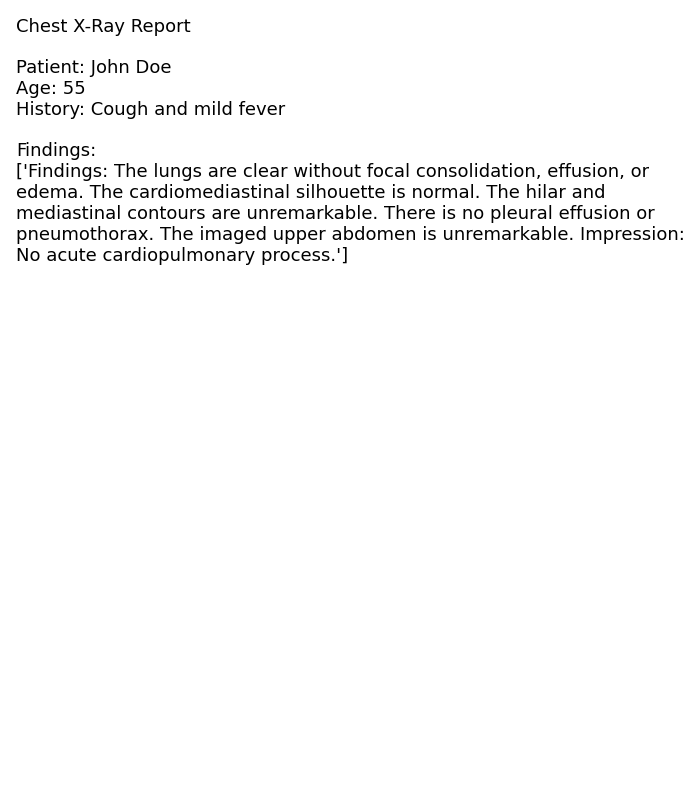

In [11]:
import matplotlib.pyplot as plt

report_text = "Chest X-Ray Report\n\nPatient: John Doe\nAge: 55\nHistory: Cough and mild fever\n\nFindings:\n" + report

fig, ax = plt.subplots(figsize=(8,10))
ax.axis('off')
plt.text(0.01, 0.99, report_text, fontsize=13, verticalalignment='top', wrap=True)
plt.savefig("/kaggle/working/sample_report.png", bbox_inches='tight')
plt.show()


In [12]:
from datetime import datetime

def generate_detailed_report(image_path, history_text="", max_new_tokens=150, num_beams=3):
    # Prepare prompt prefix with patient history
    prefix = "Patient history: " + history_text + "\nReport: "
    prefix_enc = tokenizer(prefix, return_tensors="pt").to(device)
    prefix_ids = prefix_enc["input_ids"]
    prefix_attn = prefix_enc["attention_mask"]

    # Fix image path as before
    img_path = fix_path(image_path)

    # Load and preprocess image
    im = Image.open(img_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = np.array(im).astype("float32") / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype='float32')[None, None, :]
    std = np.array([0.229, 0.224, 0.225], dtype='float32')[None, None, :]
    arr = (arr - mean) / std
    arr = np.transpose(arr, (2, 0, 1))
    pix = torch.from_numpy(arr).unsqueeze(0).to(device).float()

    # Forward pass through model to get generated text
    with torch.no_grad():
        vit_out = model.vit(pixel_values=pix).last_hidden_state
        img_emb = model.proj(vit_out)
        token_emb = model.gpt.get_input_embeddings()(prefix_ids)
        inputs_embeds = torch.cat([img_emb, token_emb], dim=1)
        img_mask = torch.ones((1, img_emb.size(1)), dtype=prefix_attn.dtype).to(device)
        new_mask = torch.cat([img_mask, prefix_attn], dim=1).to(device)
        gen_ids = model.gpt.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=new_mask,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            no_repeat_ngram_size=3,
        )
        model_report = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
        if prefix in model_report:
            model_report = model_report.split(prefix, 1)[1]

    # Define fixed or dynamic sections
    precautions = (
        "- Avoid smoking and exposure to pollutants\n"
        "- Maintain good hygiene and handwashing\n"
        "- Use a mask if in crowded places\n"
    )
    measures = (
        "- Follow prescribed medications regularly\n"
        "- Schedule follow-up X-rays monthly\n"
        "- Maintain hydration and nutrition\n"
    )
    consultancy = (
        "- Consult pulmonologist for detailed evaluation\n"
        "- Seek immediate care if symptoms worsen\n"
        "- Regularly monitor oxygen levels at home\n"
    )

    # Compose final report string
    final_report = f"""
    Chest X-Ray Report

    Clinical History:
    {history_text}

    Findings:
    {model_report}

    Precautions:
    {precautions}

    Measures:
    {measures}

    Consultancy:
    {consultancy}

    ---
    Prepared by AI Radiology Assistant
    Date: {datetime.now().strftime('%Y-%m-%d')}
    """

    return final_report.strip()


In [14]:
image_path = "/kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/p10/p10000032/s50414267/02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg"
history_text = "55-year-old female with cough and mild fever."

report = generate_detailed_report(image_path, history_text)
print(report)


Chest X-Ray Report

    Clinical History:
    55-year-old female with cough and mild fever.

    Findings:
    ['Findings: Heart size is normal. Mediastinal and hilar contours are unremarkable. Lungs are clear. No pleural effusion or pneumothorax is seen. There are no acute osseous abnormalities. Impression: No acute cardiopulmonary process.', 'Findings were discussed with _ _ _, M.D. on the telephone on _ _ at 11: 30 PM, 5 minutes after discovery of the findings. The patient is status post median sternotomy and CABG. The cardiomediastinal silhouette is within normal limits. There is no evidence of pneumonia, vascular congestion, or pleural effusion. No acute osseous abnormality is identified. The cardiac, mediastinal, and hilar structures are stable. No free air below the right hemidiaphragm is seen on

    Precautions:
    - Avoid smoking and exposure to pollutants
- Maintain good hygiene and handwashing
- Use a mask if in crowded places


    Measures:
    - Follow prescribed medica

In [18]:
from datetime import datetime

def generate_dynamic_report(image_path, history_text="", max_new_tokens=100, num_beams=3):
    """
    Generate a complete medical report with dynamic sections using trained model.
    Sections: Findings, Precautions, Measures, Consultancy
    """
    
    # Fix image path for Kaggle
    img_path = fix_path(image_path)
    
    # Load and preprocess image (once)
    im = Image.open(img_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = np.array(im).astype("float32") / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype='float32')[None, None, :]
    std = np.array([0.229, 0.224, 0.225], dtype='float32')[None, None, :]
    arr = (arr - mean) / std
    arr = np.transpose(arr, (2, 0, 1))
    pix = torch.from_numpy(arr).unsqueeze(0).to(device).float()
    
    # Get image embeddings (reuse for all sections)
    with torch.no_grad():
        vit_out = model.vit(pixel_values=pix).last_hidden_state
        img_emb = model.proj(vit_out)
    
    # Helper function to generate text for a given prompt
    def generate_section(prompt_text, max_tokens=100):
        prompt_enc = tokenizer(prompt_text, return_tensors="pt").to(device)
        prompt_ids = prompt_enc["input_ids"]
        prompt_attn = prompt_enc["attention_mask"]
        
        with torch.no_grad():
            token_emb = model.gpt.get_input_embeddings()(prompt_ids)
            inputs_embeds = torch.cat([img_emb, token_emb], dim=1)
            img_mask = torch.ones((1, img_emb.size(1)), dtype=prompt_attn.dtype).to(device)
            new_mask = torch.cat([img_mask, prompt_attn], dim=1).to(device)
            
            gen_ids = model.gpt.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=new_mask,
                max_new_tokens=max_tokens,
                num_beams=num_beams,
                no_repeat_ngram_size=2,
                temperature=0.7,
            )
            generated_text = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
            
            # Clean up: remove the prompt from output if present
            if prompt_text in generated_text:
                generated_text = generated_text.split(prompt_text, 1)[1].strip()
            
            return generated_text
    
    # Generate each section with specific prompts
    
    # 1. Findings
    findings_prompt = f"Patient history: {history_text} Radiological findings: "
    findings = generate_section(findings_prompt, max_tokens=150)
    
    # 2. Precautions
    precautions_prompt = f"Patient history: {history_text} Based on the chest X-ray, recommended precautions: "
    precautions = generate_section(precautions_prompt, max_tokens=100)
    
    # 3. Measures
    measures_prompt = f"Patient history: {history_text} Based on the chest X-ray, recommended treatment measures: "
    measures = generate_section(measures_prompt, max_tokens=100)
    
    # 4. Consultancy
    consultancy_prompt = f"Patient history: {history_text} Based on the chest X-ray, consultancy recommendations: "
    consultancy = generate_section(consultancy_prompt, max_tokens=100)
    
    # Compose final comprehensive report
    final_report = f"""
═══════════════════════════════════════════════════════════
                    CHEST X-RAY REPORT
═══════════════════════════════════════════════════════════

CLINICAL HISTORY:
{history_text if history_text else "Not provided"}

RADIOLOGICAL FINDINGS:
{findings}

PRECAUTIONS:
{precautions}

TREATMENT MEASURES:
{measures}

CONSULTANCY RECOMMENDATIONS:
{consultancy}

═══════════════════════════════════════════════════════════
Prepared by: AI Radiology Assistant (ViT + BioGPT)
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
═══════════════════════════════════════════════════════════
    """
    
    return final_report.strip()

In [19]:
model.eval()

# Example usage
image_path = "/kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/p10/p10000032/s50414267/02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg"
history_text = "55-year-old female with cough and mild fever for 3 days"

# Generate complete dynamic report
report = generate_dynamic_report(image_path, history_text, max_new_tokens=120, num_beams=3)
print(report)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


═══════════════════════════════════════════════════════════
                    CHEST X-RAY REPORT
═══════════════════════════════════════════════════════════

CLINICAL HISTORY:
55-year-old female with cough and mild fever for 3 days

RADIOLOGICAL FINDINGS:
The lungs are clear without focal consolidation, effusion, or pneumothorax. The cardiomediastinal silhouette is normal. Imaged osseous structures are intact. No free air below the right hemidiaphragm is seen. There are no acute osseous abnormalities. Surgical clips are noted in the left upper quadrant of the abdomen. A left-sided Port-A-Cath is again noted with tip terminating in mid SVC. Heart size is top normal with normal mediastinal and hilar contours. Left subclavian catheter terminates at the junction of SVC with the brachiocephalic vein. Right subclavian line ends in low SVC and ends just above the cavoatrial junction. Median sternotomy wires project over the posterior left neck and upper mediastinum, and are again seen cour


In [7]:
from datetime import datetime
import re

def generate_dynamic_report(image_path, history_text="", max_new_tokens=150, num_beams=3):
    """
    Generate a complete medical report with properly formatted sections.
    """
    
    
    img_path = fix_path(image_path)
    
    
    im = Image.open(img_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = np.array(im).astype("float32") / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype='float32')[None, None, :]
    std = np.array([0.229, 0.224, 0.225], dtype='float32')[None, None, :]
    arr = (arr - mean) / std
    arr = np.transpose(arr, (2, 0, 1))
    pix = torch.from_numpy(arr).unsqueeze(0).to(device).float()
    
    # Get image embeddings
    with torch.no_grad():
        vit_out = model.vit(pixel_values=pix).last_hidden_state
        img_emb = model.proj(vit_out)
    
    # Helper function to generate and clean text
    def generate_section(prompt_text, max_tokens=150):
        prompt_enc = tokenizer(prompt_text, return_tensors="pt").to(device)
        prompt_ids = prompt_enc["input_ids"]
        prompt_attn = prompt_enc["attention_mask"]
        
        with torch.no_grad():
            token_emb = model.gpt.get_input_embeddings()(prompt_ids)
            inputs_embeds = torch.cat([img_emb, token_emb], dim=1)
            img_mask = torch.ones((1, img_emb.size(1)), dtype=prompt_attn.dtype).to(device)
            new_mask = torch.cat([img_mask, prompt_attn], dim=1).to(device)
            
            gen_ids = model.gpt.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=new_mask,
                max_new_tokens=max_tokens,
                num_beams=num_beams,
                no_repeat_ngram_size=3,
                temperature=0.8,
            )
            generated_text = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
            
            # Clean artifacts (quotes, extra symbols)
            generated_text = re.sub(r"["",[]]", "", generated_text)
            generated_text = generated_text.strip()
            
            return generated_text
    
    # 1. Generate FINDINGS (model-based)
    findings_prompt = f"Patient history: {history_text} Chest X-ray findings: "
    findings_raw = generate_section(findings_prompt, max_tokens=200)
    
    # Clean and extract only relevant findings
    findings = findings_raw.replace(findings_prompt, "").strip()
    
    # 2. Generate context-aware sections based on findings
    # Extract keywords for rule-based generation
    findings_lower = findings.lower()
    
    # PRECAUTIONS (rule-based with context)
    precautions = []
    if any(word in findings_lower for word in ["clear", "normal", "no acute"]):
        precautions = [
            "Maintain good respiratory hygiene and hand washing",
            "Ensure adequate rest and hydration",
            "Monitor symptoms and report any worsening",
            "Avoid exposure to sick contacts",
        ]
    elif any(word in findings_lower for word in ["consolidation", "pneumonia", "infiltrate"]):
        precautions = [
            "Strict respiratory isolation if infectious cause suspected",
            "Use of mask when around others",
            "Frequent hand hygiene",
            "Avoid smoking and secondhand smoke exposure",
            "Monitor oxygen saturation regularly",
        ]
    elif any(word in findings_lower for word in ["effusion", "fluid"]):
        precautions = [
            "Monitor for breathing difficulty",
            "Elevate head of bed during rest",
            "Limit sodium intake to reduce fluid retention",
            "Regular weight monitoring",
        ]
    else:
        precautions = [
            "Follow respiratory hygiene practices",
            "Avoid exposure to pollutants and allergens",
            "Maintain adequate hydration",
            "Report any new or worsening symptoms promptly",
        ]
    
    # TREATMENT MEASURES (rule-based with context)
    measures = []
    if any(word in findings_lower for word in ["clear", "normal", "no acute"]):
        measures = [
            "Continue symptomatic treatment for cough and fever",
            "Antipyretics as needed for fever management",
            "Adequate fluid intake (2-3 liters per day)",
            "Rest and avoid strenuous activity",
            "Follow-up if symptoms persist beyond 7 days",
        ]
    elif any(word in findings_lower for word in ["consolidation", "pneumonia", "infiltrate"]):
        measures = [
            "Initiate appropriate antibiotic therapy as per guidelines",
            "Consider chest physiotherapy",
            "Oxygen supplementation if SpO2 < 94%",
            "Bronchodilators if wheezing present",
            "Repeat chest X-ray in 4-6 weeks to assess resolution",
        ]
    elif any(word in findings_lower for word in ["cardiomegaly", "cardiac", "heart"]):
        measures = [
            "Optimize cardiac medications",
            "Diuretics for fluid management",
            "Echocardiography for cardiac assessment",
            "Low sodium diet",
            "Daily weight monitoring",
        ]
    else:
        measures = [
            "Supportive care with rest and fluids",
            "Symptomatic treatment as appropriate",
            "Monitor vital signs regularly",
            "Consider further imaging if clinically indicated",
        ]
    
    # CONSULTANCY RECOMMENDATIONS (rule-based with context)
    consultancy = []
    if any(word in findings_lower for word in ["clear", "normal", "no acute"]):
        consultancy = [
            "Follow-up with primary care physician in 1 week if symptoms persist",
            "Return to emergency department if developing shortness of breath or high fever",
        ]
    elif any(word in findings_lower for word in ["consolidation", "pneumonia", "infiltrate"]):
        consultancy = [
            "Immediate consultation with pulmonologist recommended",
            "Consider infectious disease consultation if atypical presentation",
            "Follow-up chest X-ray in 4-6 weeks to ensure resolution",
            "Return immediately if worsening dyspnea or hypoxia",
        ]
    elif any(word in findings_lower for word in ["cardiomegaly", "effusion", "cardiac"]):
        consultancy = [
            "Urgent cardiology consultation recommended",
            "Echocardiography within 24-48 hours",
            "Consider BNP/pro-BNP levels",
            "Close monitoring of fluid status",
        ]
    elif any(word in findings_lower for word in ["mass", "nodule", "lesion"]):
        consultancy = [
            "Urgent referral to pulmonology for further evaluation",
            "CT chest with contrast recommended",
            "Consider biopsy or bronchoscopy as clinically indicated",
        ]
    else:
        consultancy = [
            "Follow-up with primary care physician within 3-5 days",
            "Specialist consultation if symptoms worsen or persist",
            "Repeat imaging if clinically warranted",
        ]
    
    # Format sections as bullet points
    precautions_text = "".join([f"  • {item}" for item in precautions])
    measures_text = "".join([f"  • {item}" for item in measures])
    consultancy_text = "".join([f"  • {item}" for item in consultancy])
    
    # Compose final report
    final_report = f"""
═══════════════════════════════════════════════════════════
                    CHEST X-RAY REPORT
═══════════════════════════════════════════════════════════

CLINICAL HISTORY:
{history_text if history_text else "Not provided"}

RADIOLOGICAL FINDINGS:
{findings}

PRECAUTIONS:
{precautions_text}

TREATMENT MEASURES:
{measures_text}

CONSULTANCY RECOMMENDATIONS:
{consultancy_text}

═══════════════════════════════════════════════════════════
Prepared by: AI Radiology Assistant (ViT + BioGPT)
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
═══════════════════════════════════════════════════════════
    """
    
    return final_report.strip()

In [28]:
model.eval()

image_path = "/kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/p15/p15000170/s56450978/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c.jpg"
history_text = "He is 75 years old suffering from breathing problem and pressure in heart"

report = generate_dynamic_report(image_path, history_text)
print(report)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


═══════════════════════════════════════════════════════════
                    CHEST X-RAY REPORT
═══════════════════════════════════════════════════════════

CLINICAL HISTORY:
He is 75 years old suffering from breathing problem and pressure in heart

RADIOLOGICAL FINDINGS:
The lungs are clear without focal consolidation. No pleural effusion or pneumothorax is seen. The cardiac and mediastinal silhouettes are unremarkable. Impression: No acute cardiopulmonary process. ',' Findings: PA and lateral views of the chest provided. There is no focal consolidation, effusion, or pneumothorax. The cardiomediastinal and hilar contours are normal. Imaged osseous structures are intact. No free air below the right hemidiaphragm is seen Impression, '] 국 and 1-3 PM, respectively, of these findings were communicated via telephone to Dr. _ _ _ at 11: 45 a.m. on _ _, at the time of discovery of the findings. The findings were discussed over the telephone by Dr.-_ _ with Dr. _ * _ _ on the telephone at t

Device: cuda
Saved dir exists: True  checkpoint exists: True
Loading tokenizer and saved component model folders (if present)...
Loaded tokenizer from /kaggle/working/models/vit_biogpt_multimodal_onfly
Loaded ViT from /kaggle/working/models/vit_biogpt_multimodal_onfly/vit
Loaded BioGPT from /kaggle/working/models/vit_biogpt_multimodal_onfly/biogpt
Loading checkpoint: /kaggle/working/models/vit_biogpt_multimodal_onfly/best_multimodal_onfly.pt
Loaded checkpoint into wrapper (strict).
Enter path to image (JPG/PNG or .npz). Example: /kaggle/input/.../s50414267.jpg


Image path:  /kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/p15/p15000170/s56450978/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c.jpg


Enter patient history text (single line or multi-line). Finish with ENTER.


History:  45 year old with mild pain in the chest and has breathing problem


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Generating report — this may take a little while depending on model size...

Raw model output (first 800 chars):
 ", 'Findings: Impression: In comparison with the earlier study of this date, there has been placement of a right pigtail catheter that extends to the right upper quadrant. There is no evidence of pneumothorax. Otherwise, little change in the appearance of the heart and lungs.'," Findings were discussed with Dr. _ _, _ 12: 45 PM, 5 minutes after discovery. The lungs are clear without consolidation, effusion, or edema. Cardiomediastinal silhouette is within normal limits. No acute osseous abnormalities identified. A right-sided chest tube is noted, with its tip projecting over the upper right lung, unchanged from the prior study. Right upper rib fractures are again noted. Dr. was paged at the time of discovery as soon as the findings were communicated. "], 3 days prior to observation, the ch 
---

Report image saved to: /kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac

/kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.png

/kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.pdf


Parsed structured report:
{
  "Key Findings": [
    "No specific content generated."
  ],
  "Impression": [
    "In comparison with the earlier study of this date, there has been placement of a right pigtail catheter that extends to the right upper quadrant. There is no evidence of pneumothorax. Otherwise, little change in the appearance of the heart and lungs.',\" Findings were discussed with Dr. _ _, _ 12: 45 PM, 5 minutes after discovery. The lungs are clear without consolidation, effusion, or edema. Cardiomediastinal silhouette is within normal limits. No acute osseous abnormalities identified. A right-sided chest tube is noted, with its tip projecting over the upper right lung, unchanged from the prior study. Right upper rib fractures are again noted. Dr. was paged at the time of discovery as soon as the findings were communicated. \"], 3 days prior to observation, the chest tubes were removed, and the patient has received a chest drain. Imaged areas are grossly unremarkable. Hea

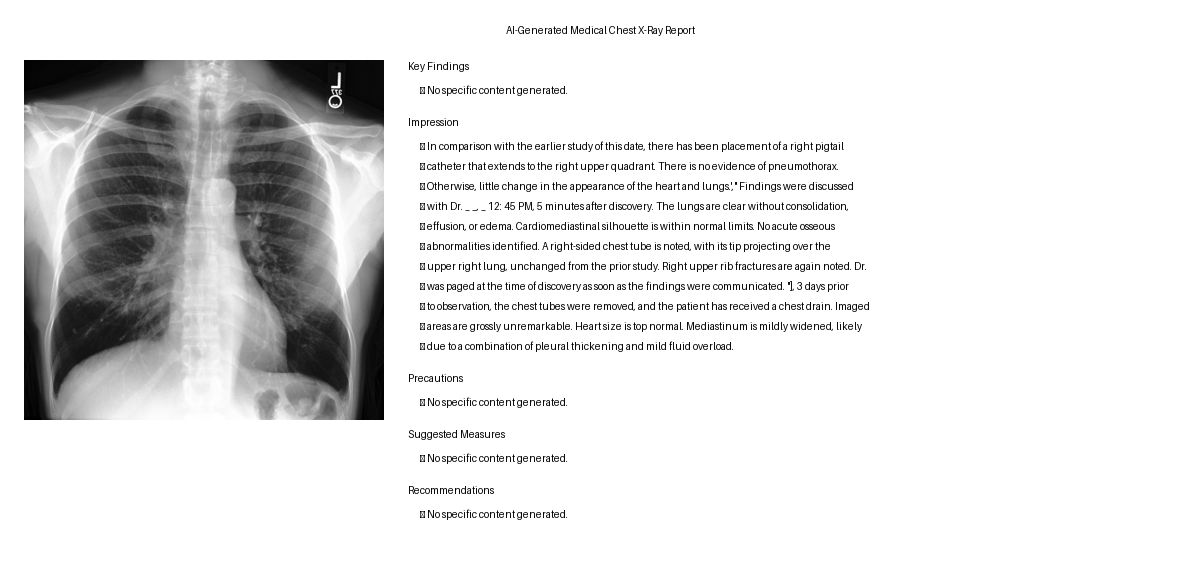

('/kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.png',
 '/kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.pdf',
 {'Key Findings': ['No specific content generated.'],
  'Impression': ['In comparison with the earlier study of this date, there has been placement of a right pigtail catheter that extends to the right upper quadrant. There is no evidence of pneumothorax. Otherwise, little change in the appearance of the heart and lungs.\'," Findings were discussed with Dr. _ _, _ 12: 45 PM, 5 minutes after discovery. The lungs are clear without consolidation, effusion, or edema. Cardiomediastinal silhouette is within normal limits. No acute osseous abnormalities identified. A right-sided chest tube is noted, with its tip projecting over the upper right lung, unchanged from the prior study. Right upper rib fractures are again noted. Dr. was paged at the time of discovery as soon as the findings were communicated. "], 3 days prior t

In [29]:
# Interactive generator: load checkpoint, prompt for inputs, generate structured bullet report image + PDF
import os, json, re, shutil
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import torch
import torch.nn as nn
from transformers import ViTModel, AutoModelForCausalLM, AutoTokenizer
from IPython.display import display, FileLink, HTML

# ---------- CONFIG ----------
SAVED_DIR = Path("/kaggle/working/models/vit_biogpt_multimodal_onfly")
BEST_CKPT = SAVED_DIR / "best_multimodal_onfly.pt"
OUT_FOLDER = Path("/kaggle/working/reports")
OUT_FOLDER.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 224
# ----------------------------

print("Device:", DEVICE)
print("Saved dir exists:", SAVED_DIR.exists(), " checkpoint exists:", BEST_CKPT.exists())

# ---------- load tokenizer + component models ----------
print("Loading tokenizer and saved component model folders (if present)...")
tokenizer = None
vit = None
biogpt = None

# Load tokenizer if saved in directory root
try:
    tokenizer = AutoTokenizer.from_pretrained(SAVED_DIR)
    print("Loaded tokenizer from", SAVED_DIR)
except Exception as e:
    print("Tokenizer load failed from", SAVED_DIR, " — will try alternative. Error:", e)

# load vit & biogpt folders if present
try:
    if (SAVED_DIR / "vit").exists():
        vit = ViTModel.from_pretrained(SAVED_DIR / "vit").to(DEVICE)
        print("Loaded ViT from", SAVED_DIR / "vit")
    else:
        print("No vit/ folder found under saved dir.")
except Exception as e:
    print("Failed to load ViT:", e)

try:
    if (SAVED_DIR / "biogpt").exists():
        biogpt = AutoModelForCausalLM.from_pretrained(SAVED_DIR / "biogpt").to(DEVICE)
        print("Loaded BioGPT from", SAVED_DIR / "biogpt")
    else:
        print("No biogpt/ folder found under saved dir.")
except Exception as e:
    print("Failed to load BioGPT:", e)

if tokenizer is None:
    # as fallback, try to load model tokenizer directly from biogpt folder if exists
    try:
        tokenizer = AutoTokenizer.from_pretrained(SAVED_DIR / "biogpt")
        print("Loaded tokenizer from biogpt folder")
    except Exception as e:
        print("No tokenizer found. Please ensure tokenizer files exist under", SAVED_DIR)
        raise SystemExit("Tokenizer missing. Cannot proceed.")

# ---------- wrapper class with projection ----------
class BioGPTMultimodalWrapper(nn.Module):
    def __init__(self, vit_model: ViTModel, gpt_model: AutoModelForCausalLM):
        super().__init__()
        self.vit = vit_model
        self.gpt = gpt_model
        # projection to match gpt hidden size
        self.proj = nn.Linear(vit_model.config.hidden_size, gpt_model.config.hidden_size)

    def forward(self, pixel_values, input_ids=None, attention_mask=None, labels=None):
        vit_out = self.vit(pixel_values=pixel_values).last_hidden_state  # [B, n_img, vit_h]
        img_emb = self.proj(vit_out)                                      # [B, n_img, gpt_h]
        token_emb = self.gpt.get_input_embeddings()(input_ids)           # [B, seq, gpt_h]
        inputs_embeds = torch.cat([img_emb, token_emb], dim=1)
        # attention mask: prepend ones for image tokens
        img_mask = torch.ones((attention_mask.size(0), img_emb.size(1)), dtype=attention_mask.dtype, device=attention_mask.device)
        new_attn = torch.cat([img_mask, attention_mask], dim=1)
        if labels is not None:
            pad = torch.full((labels.size(0), img_emb.size(1)), -100, dtype=labels.dtype, device=labels.device)
            new_labels = torch.cat([pad, labels], dim=1)
        else:
            new_labels = None
        return self.gpt(inputs_embeds=inputs_embeds, attention_mask=new_attn, labels=new_labels, return_dict=True)

if vit is None or biogpt is None:
    raise SystemExit("ViT or BioGPT component not loaded. Ensure you saved component folders under SAVED_DIR/vit and SAVED_DIR/biogpt.")

wrapper = BioGPTMultimodalWrapper(vit, biogpt).to(DEVICE)

# ---------- load checkpoint safely (handle prefix mismatches) ----------
if BEST_CKPT.exists():
    print("Loading checkpoint:", BEST_CKPT)
    ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
    state = None
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state = ckpt["model_state_dict"]
    elif isinstance(ckpt, dict):
        # maybe raw state dict
        state = ckpt
    else:
        state = ckpt

    # attempt direct load
    try:
        wrapper.load_state_dict(state, strict=True)
        print("Loaded checkpoint into wrapper (strict).")
    except Exception as e:
        print("Strict load failed:", e)
        # try prefix cleanup
        cleaned = {}
        for k,v in state.items():
            newk = k
            for prefix in ("module.", "model.", "wrapper.", "model_state_dict."):
                if newk.startswith(prefix):
                    newk = newk[len(prefix):]
            cleaned[newk] = v
        try:
            wrapper.load_state_dict(cleaned, strict=False)
            print("Loaded checkpoint into wrapper (loose).")
        except Exception as e2:
            print("Loose load also failed:", e2)
            print("Proceeding with wrapper where proj weights may be random.")
else:
    print("Checkpoint not found at", BEST_CKPT)
    print("Wrapper currently has random projection weights; generation quality will be degraded.")

# ---------- utilities: load image tensor (.npz or raw image) ----------
def load_image_tensor(path, image_size=IMAGE_SIZE, device=DEVICE):
    p = str(path)
    if p.lower().endswith(".npz"):
        d = np.load(p, allow_pickle=True)
        pix = torch.from_numpy(d["pixel"].astype("float32"))
        if pix.max() <= 5.0 and pix.min() >= -5.0:
            mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
            std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
            pix = pix * std + mean
            pix = torch.clamp(pix, 0.0, 1.0)
        else:
            if pix.max() > 1.5:
                pix = pix / 255.0
        if pix.shape[1] != image_size or pix.shape[2] != image_size:
            pix = pix.unsqueeze(0)
            pix = nn.functional.interpolate(pix, size=(image_size, image_size), mode='bilinear', align_corners=False).squeeze(0)
        pix = pix.unsqueeze(0).to(device)
        return pix
    else:
        img = Image.open(p).convert("RGB").resize((image_size, image_size))
        arr = np.array(img).astype("float32")/255.0
        mean = np.array([0.485,0.456,0.406], dtype='float32')[None,None,:]
        std  = np.array([0.229,0.224,0.225], dtype='float32')[None,None,:]
        arr = (arr - mean) / std
        arr = np.transpose(arr, (2,0,1))
        pix = torch.from_numpy(arr).unsqueeze(0).to(device)
        # invert normalization back to 0..1 for ViT-like expected input (we used this earlier)
        pix = pix * torch.tensor(std).view(1,3,1,1).to(device) + torch.tensor(mean).view(1,3,1,1).to(device)
        pix = torch.clamp(pix, 0.0, 1.0)
        return pix

# ---------- prompt builder & raw generator ----------
def build_structured_prompt(history_text):
    sections = ["Key Findings","Impression","Precautions","Suggested Measures","Recommendations"]
    prompt = f"""You are an expert radiologist. Based on the image and the patient history below, produce a JSON object with these keys exactly: {json.dumps(sections)}.
Each value should be an array of 1-6 concise bullet strings (no numbering). Avoid administrative / pager text. If unsure, state uncertainty.
Patient history: \"{history_text if history_text else 'None provided.'}\"

Return ONLY the JSON object.
"""
    return prompt

def generate_raw_text(image_tensor, history_text, max_new_tokens=200, num_beams=3, temperature=0.0):
    wrapper.eval()
    prompt = build_structured_prompt(history_text)
    enc = tokenizer(prompt, return_tensors="pt", truncation=True, padding=True).to(DEVICE)
    prefix_ids = enc["input_ids"]
    prefix_attn = enc["attention_mask"]
    with torch.no_grad():
        vit_out = wrapper.vit(pixel_values=image_tensor).last_hidden_state
        img_emb = wrapper.proj(vit_out)
        token_emb = wrapper.gpt.get_input_embeddings()(prefix_ids)
        inputs_embeds = torch.cat([img_emb, token_emb], dim=1)
        img_mask = torch.ones((1, img_emb.size(1)), dtype=prefix_attn.dtype).to(DEVICE)
        new_mask = torch.cat([img_mask, prefix_attn], dim=1).to(DEVICE)
        gen_ids = wrapper.gpt.generate(inputs_embeds=inputs_embeds,
                                       attention_mask=new_mask,
                                       max_new_tokens=max_new_tokens,
                                       num_beams=num_beams,
                                       temperature=temperature,
                                       no_repeat_ngram_size=2,
                                       early_stopping=True)
        out = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
        # if model echoed prompt, strip
        if prompt.strip() and prompt.strip() in out:
            out = out.split(prompt.strip(),1)[-1].strip()
        return out

# ---------- parser to get lists for each section ----------
def parse_structured_output(raw_text):
    sections = ["Key Findings","Impression","Precautions","Suggested Measures","Recommendations"]
    # try JSON extraction
    try:
        m = re.search(r"(\{[\s\S]*\})", raw_text)
        if m:
            cand = m.group(1)
            parsed = json.loads(cand)
            result = {}
            for s in sections:
                v = parsed.get(s, [])
                if isinstance(v, str):
                    lines = [ln.strip() for ln in re.split(r"[\r\n]+|-{2,}|\u2022|•", v) if ln.strip()]
                    result[s] = lines if lines else ([v.strip()] if v.strip() else [])
                elif isinstance(v, list):
                    result[s] = [str(x).strip() for x in v if str(x).strip()]
                else:
                    result[s] = []
            return result
    except Exception as e:
        pass
    # fallback: headings search
    result = {}
    for s in sections:
        pat = re.compile(rf"{re.escape(s)}\s*:?\s*(.*?)(?=(Key Findings|Impression|Precautions|Suggested Measures|Recommendations)\s*:|\Z)", flags=re.I|re.S)
        m = pat.search(raw_text)
        if m:
            body = m.group(1).strip()
            bullets = [b.strip(" -•") for b in re.split(r"[\n\r]+|-{2,}|\u2022|•", body) if b.strip()]
            result[s] = bullets if bullets else [body]
        else:
            result[s] = []
    return result

# ---------- renderer: thumbnail left, bullets right ----------
def _wrap_text(text, max_chars=60):
    words = text.split()
    lines = []
    cur = []
    cur_len = 0
    for w in words:
        if cur_len + len(w) + 1 > max_chars:
            lines.append(" ".join(cur))
            cur = [w]
            cur_len = len(w)
        else:
            cur.append(w)
            cur_len += len(w) + 1
    if cur:
        lines.append(" ".join(cur))
    return lines

def render_report_with_thumbnail(image_path, report_dict, out_png, title="AI-Generated Medical Chest X-Ray Report",
                                 width=1200, margin=24, thumb_w=360):
    # load source image as thumbnail
    try:
        src = Image.open(image_path).convert("RGB")
    except Exception:
        # if npz, try read pixel
        if str(image_path).lower().endswith(".npz"):
            d = np.load(image_path, allow_pickle=True)
            pix = d["pixel"]
            if pix.max() <= 5 and pix.min() >= -5:
                mean = np.array([0.485,0.456,0.406])[None,None,:]
                std  = np.array([0.229,0.224,0.225])[None,None,:]
                arr = pix * std + mean
            else:
                arr = pix
            arr = (np.clip(arr,0,1).transpose(1,2,0)*255).astype('uint8')
            src = Image.fromarray(arr)
        else:
            src = Image.new("RGB",(IMAGE_SIZE,IMAGE_SIZE),"grey")
    # compute layout
    thumb_h = int(thumb_w * src.height / src.width)
    thumb = src.resize((thumb_w, thumb_h))
    # fonts
    try:
        title_font = ImageFont.truetype("DejaVuSans-Bold.ttf", 28)
        heading_font = ImageFont.truetype("DejaVuSans.ttf", 20)
        body_font = ImageFont.truetype("DejaVuSans.ttf", 16)
    except Exception:
        title_font = ImageFont.load_default()
        heading_font = ImageFont.load_default()
        body_font = ImageFont.load_default()

    # estimate height
    text_area_w = width - thumb_w - 3*margin
    cur_y = margin
    # title height
    cur_y += 36
    for sec, items in report_dict.items():
        cur_y += 28
        if items:
            for it in items:
                wrapped = _wrap_text(it, max_chars= int(text_area_w/8))
                cur_y += len(wrapped) * 20 + 4
        else:
            cur_y += 20 + 4
        cur_y += 6
    total_h = max(cur_y + margin, thumb_h + 2*margin)
    img = Image.new("RGB", (width, total_h), "white")
    draw = ImageDraw.Draw(img)
    # draw title centered across full width
    wtitle = draw.textlength(title, font=title_font) if hasattr(draw, "textlength") else len(title)*10
    draw.text(((width-wtitle)/2, margin), title, fill="black", font=title_font)
    y = margin + 36
    # paste thumbnail left
    img.paste(thumb, (margin, y))
    # text start
    tx = margin + thumb_w + margin
    ty = y
    for sec, items in report_dict.items():
        draw.text((tx, ty), sec, font=heading_font, fill="black")
        ty += 24
        if items:
            for it in items:
                wrapped = _wrap_text(it, max_chars=int(text_area_w/8))
                for line in wrapped:
                    draw.text((tx+12, ty), "• " + line, font=body_font, fill="black")
                    ty += 20
                ty += 4
        else:
            draw.text((tx+12, ty), "None", font=body_font, fill="black")
            ty += 20
        ty += 8
    # save
    out_png = Path(out_png)
    out_png.parent.mkdir(parents=True, exist_ok=True)
    img.save(str(out_png))
    return str(out_png)

# ---------- save PNG -> PDF ----------
def png_to_pdf(png_path, pdf_path):
    im = Image.open(png_path).convert('RGB')
    im.save(pdf_path, "PDF", resolution=100.0)
    return str(pdf_path)

# ---------- interactive prompt, generation, save, show links ----------
def interactive_generate_and_save():
    print("Enter path to image (JPG/PNG or .npz). Example: /kaggle/input/.../s50414267.jpg")
    image_path = input("Image path: ").strip()
    if not image_path:
        print("No path entered. Aborting.")
        return
    if not Path(image_path).exists():
        print("File not found:", image_path)
        return
    print("Enter patient history text (single line or multi-line). Finish with ENTER.")
    history_text = input("History: ").strip()

    print("\nGenerating report — this may take a little while depending on model size...")
    image_tensor = load_image_tensor(image_path, image_size=IMAGE_SIZE, device=DEVICE)
    raw = generate_raw_text(image_tensor, history_text, max_new_tokens=220, num_beams=3, temperature=0.0)
    print("\nRaw model output (first 800 chars):\n", raw[:800], "\n---\n")
    parsed = parse_structured_output(raw)
    # ensure non-empty lists
    for k in ["Key Findings","Impression","Precautions","Suggested Measures","Recommendations"]:
        parsed[k] = [x.strip() for x in parsed.get(k,[]) if x and x.strip()]
        if len(parsed[k]) == 0:
            parsed[k] = ["No specific content generated."]

    # save report image and PDF
    base = Path(image_path).stem
    out_png = OUT_FOLDER / f"{base}_AI_report.png"
    out_pdf = OUT_FOLDER / f"{base}_AI_report.pdf"
    png_path = render_report_with_thumbnail(image_path, parsed, out_png)
    pdf_path = png_to_pdf(png_path, out_pdf)

    print("Report image saved to:", png_path)
    print("Report PDF saved to:", pdf_path)
    display(HTML(f"<b>Download links:</b><br><a href='{png_path}' target='_blank'>Download PNG</a><br><a href='{pdf_path}' target='_blank'>Download PDF</a>"))
    # also display file links (clickable)
    try:
        display(FileLink(png_path))
        display(FileLink(pdf_path))
    except Exception:
        pass
    # show parsed JSON
    print("\nParsed structured report:")
    print(json.dumps(parsed, indent=2))
    # display PNG inline
    try:
        display(Image.open(png_path))
    except Exception:
        pass
    return str(png_path), str(pdf_path), parsed, raw

# run interactive function
interactive_generate_and_save()


In [34]:
# ---------------- Improved generation + fallback filling ----------------
import re, json, torch

# Set these if not present in your notebook
# wrapper, tokenizer, DEVICE, IMAGE_SIZE, render_report_with_thumbnail, png_to_pdf must exist

def build_fewshot_prompt(history_text):
    # Provide a short example to show exactly the JSON format we want.
    example = {
      "Key Findings": [
        "Right perihilar airspace opacity consistent with consolidation.",
        "No pleural effusion identified.",
        "Endotracheal tube tip projects approximately 3 cm above the carina."
      ],
      "Impression": [
        "Right lower-lobe pneumonia.",
        "Airway device in expected position.",
        "No acute cardiopulmonary disease otherwise."
      ],
      "Precautions": [
        "Isolate if infectious etiology suspected.",
        "Monitor oxygen saturation and respiratory status."
      ],
      "Suggested Measures": [
        "Obtain follow-up chest radiograph in 24–48 hours.",
        "Consider empiric antibiotics for community-acquired pneumonia."
      ],
      "Recommendations": [
        "Correlate with clinical exam and labs (CBC, CRP).",
        "If worsening, consider CT chest for further evaluation."
      ]
    }
    instr = (
        "You are an expert radiologist. Produce a JSON object with EXACT keys: "
        "[\"Key Findings\",\"Impression\",\"Precautions\",\"Suggested Measures\",\"Recommendations\"].\n"
        "Each value must be an array of 1–6 concise bullet strings. Do NOT include administrative notes.\n"
        "Here is an example of the EXACT format:\n\n"
        + json.dumps(example, indent=2) +
        "\n\nNow analyze the image and the patient history below and RETURN ONLY one JSON object in the same format.\n"
        f"Patient history: \"{history_text if history_text else 'None provided'}\"\n\n"
    )
    return instr

def fallback_extract(raw_text, sections=None):
    # Populate empty sections by extracting sentences with clinical keywords
    if sections is None:
        sections = ["Key Findings","Impression","Precautions","Suggested Measures","Recommendations"]
    # split into sentences
    sents = re.split(r'(?<=[.!?])\s+', raw_text.replace('\n',' ').strip())
    keywords = {
        "Key Findings": r"(consolidation|infiltrate|opacity|effusion|pneumothorax|cardiomegaly|tube|intub|nasogastric|fracture|rib|atelectasis|hyperinflation|edema)",
        "Impression": r"(impression|likely|consistent with|probable|suggestive of|diagnosis|no acute)",
        "Precautions": r"(isolate|precaution|monitor|watch|observe|urgent|emergency)",
        "Suggested Measures": r"(follow-up|obtain|consider|recommend|start|administer|treatment|antibiotic|oxygen)",
        "Recommendations": r"(recommend|advise|follow-up|refer|CT|consult|repeat)"
    }
    out = {s: [] for s in sections}
    for sent in sents:
        for sec, pat in keywords.items():
            if re.search(pat, sent, flags=re.I):
                # keep short cleaned sentence
                cleaned = sent.strip().strip(' .;,:')
                if len(cleaned) > 10 and cleaned not in out[sec]:
                    out[sec].append(cleaned)
    # trim to up to 4 items each
    for k in out:
        out[k] = out[k][:4]
    return out

def generate_structured_report_with_fallback(image_path, history_text, max_new_tokens=300, num_beams=4, temperature=0.0, top_p=0.95):
    # prepare image tensor
    pix = load_image_tensor(image_path, image_size=IMAGE_SIZE, device=DEVICE)
    prompt = build_fewshot_prompt(history_text)
    enc = tokenizer(prompt, return_tensors="pt", truncation=True).to(DEVICE)
    prefix_ids = enc["input_ids"]
    prefix_attn = enc["attention_mask"]
    with torch.no_grad():
        vit_out = wrapper.vit(pixel_values=pix).last_hidden_state
        img_emb = wrapper.proj(vit_out)
        token_emb = wrapper.gpt.get_input_embeddings()(prefix_ids)
        inputs_embeds = torch.cat([img_emb, token_emb], dim=1)
        img_mask = torch.ones((1, img_emb.size(1)), dtype=prefix_attn.dtype).to(DEVICE)
        new_mask = torch.cat([img_mask, prefix_attn], dim=1).to(DEVICE)
        gen_ids = wrapper.gpt.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=new_mask,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            temperature=temperature,
            top_p=top_p,
            no_repeat_ngram_size=3,
            early_stopping=True
        )
        raw = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
    # try parse JSON
    parsed = {}
    try:
        m = re.search(r"(\{[\s\S]*\})", raw)
        if m:
            parsed = json.loads(m.group(1))
    except Exception:
        parsed = {}
    # normalize expected keys
    keys = ["Key Findings","Impression","Precautions","Suggested Measures","Recommendations"]
    for k in keys:
        if k not in parsed or not parsed[k]:
            parsed.setdefault(k, [])
    # fallback filling: if any key empty, try to extract from raw_text
    any_empty = any(len(parsed[k])==0 for k in keys)
    if any_empty:
        extracted = fallback_extract(raw)
        for k in keys:
            if len(parsed.get(k,[]))==0 and extracted.get(k):
                parsed[k] = extracted[k]
    # final safeguard: ensure non-empty lists
    for k in keys:
        if not parsed.get(k):
            parsed[k] = ["No specific content generated."]
    return parsed, raw

# Example usage (interactive):
image_path = input("Enter image path: ").strip()
history_text = input("Enter patient history (single line): ").strip()
parsed, raw = generate_structured_report_with_fallback(image_path, history_text, max_new_tokens=300, num_beams=4, temperature=0.0, top_p=0.95)
print("Parsed JSON:\n", json.dumps(parsed, indent=2))

# Save image+pdf as before
out_png = OUT_FOLDER / (Path(image_path).stem + "_AI_report.png")
render_report_with_thumbnail(image_path, parsed, out_png)
out_pdf = OUT_FOLDER / (Path(image_path).stem + "_AI_report.pdf")
png_to_pdf(str(out_png), str(out_pdf))
print("Saved:", out_png, out_pdf)


Enter image path:  /kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/p15/p15000170/s56450978/6b53b66e-2871db03-cfbc3045-4e17bd5b-62902490.jpg
Enter patient history (single line):  55 year old with breathing problem and chest pain for past three days


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Parsed JSON:
 {
  "Key Findings": [
    "However, in the appropriate clinical setting, it would be very difficult to exclude the possibility of supervening pulmonary edema.', \"Findings: Frontal and lateral views of the chest were obtained",
    "The lungs are clear without focal consolidation, effusion, or pneumothorax",
    "No displaced rib fractures are seen",
    "There has been interval removal of the endotracheal tube and right PICC line"
  ],
  "Impression": [
    "'Findings: Impression: In comparison with the study of _ _ _, the patient has taken a better inspiration",
    "No acute osseous abnormality is identified",
    "Impression.\", '] and 3 p.m., respectively, the findings were discussed with Dr"
  ],
  "Precautions": [
    "No specific content generated."
  ],
  "Suggested Measures": [
    "However, in the appropriate clinical setting, it would be very difficult to exclude the possibility of supervening pulmonary edema.', \"Findings: Frontal and lateral views of the che

---------------------------------------------------------------------------------------------

In [35]:
def build_clean_prompt(history_text):
    return (
        "You are an expert radiologist.\n"
        "Based on the chest X-ray image and the patient history, "
        "produce a clean, concise medical report.\n\n"
        "⚠️ STRICT RULES:\n"
        "- Output ONLY bullet points (no paragraphs)\n"
        "- Each bullet must describe ONE important clinical observation\n"
        "- No administrative content (no doctor calls, timestamps, etc.)\n"
        "- No irrelevant details (only radiology-relevant)\n"
        "- 6–12 bullet points maximum\n\n"
        f"Patient History: {history_text}\n\n"
        "Now generate the bullet-point medical report:\n"
    )


In [36]:
def generate_bullet_report(image_path, history_text, max_tokens=250):
    pix = load_image_tensor(image_path, image_size=IMAGE_SIZE, device=DEVICE)

    prompt = build_clean_prompt(history_text)
    enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        vit_out = wrapper.vit(pixel_values=pix).last_hidden_state
        img_emb = wrapper.proj(vit_out)

        tok_emb = wrapper.gpt.get_input_embeddings()(enc["input_ids"])
        inputs_embeds = torch.cat([img_emb, tok_emb], dim=1)

        mask_img = torch.ones((1, img_emb.size(1)), dtype=enc["attention_mask"].dtype).to(DEVICE)
        attn = torch.cat([mask_img, enc["attention_mask"]], dim=1)

        gen_ids = wrapper.gpt.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=attn,
            max_new_tokens=max_tokens,
            num_beams=4,
            temperature=0.2,
            no_repeat_ngram_size=3
        )

        text = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
        # remove prompt
        return text.replace(prompt, "").strip()


In [37]:
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path

def render_bullet_report(image_path, bullets_text, out_png_path):
    # create blank white canvas
    W, H = 1400, 1800
    img = Image.new("RGB", (W, H), "white")
    draw = ImageDraw.Draw(img)

    # fonts
    title_font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 48)
    text_font  = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 34)

    # Title
    title = "AI-Generated Medical Chest X-Ray Report"
    tw, th = draw.textsize(title, font=title_font)
    draw.text(((W-tw)//2, 40), title, font=title_font, fill="black")

    # Thumbnail
    thumb = Image.open(image_path).convert("RGB")
    thumb.thumbnail((600, 600))
    img.paste(thumb, (50, 150))

    # Bullet text formatting
    x0, y0 = 700, 150
    line_height = 50

    for line in bullets_text.split("\n"):
        if not line.strip():
            continue
        txt = "• " + line.strip("-• ")
        draw.text((x0, y0), txt, font=text_font, fill="black")
        y0 += line_height

    img.save(out_png_path)
    return out_png_path


In [38]:
def save_pdf_from_png(png_path, pdf_path):
    img = Image.open(png_path).convert("RGB")
    img.save(pdf_path, "PDF", resolution=100.0)


this is the main


In [41]:
# Single robust cell: generate bullet report, render PNG, save PDF, show download links
import os, json, re, shutil
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import torch
from IPython.display import FileLink, display, HTML

# ---------------- CONFIG ----------------
OUT_DIR = Path("/kaggle/working/reports")
OUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 224
# Ensure wrapper and tokenizer exist
# wrapper: your BioGPTMultimodalWrapper instance (has .vit, .proj, .gpt)
# tokenizer: HF tokenizer
assert 'wrapper' in globals() and 'tokenizer' in globals(), "Please load `wrapper` and `tokenizer` first."

# ---------------- helper: load image tensor (same as before) ----------------
def load_image_tensor(path, image_size=IMAGE_SIZE, device=DEVICE):
    p = str(path)
    if p.lower().endswith(".npz"):
        d = np.load(p, allow_pickle=True)
        pix = torch.from_numpy(d["pixel"].astype("float32"))
        if pix.max() <= 5.0 and pix.min() >= -5.0:
            mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
            std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
            pix = pix * std + mean
            pix = torch.clamp(pix, 0.0, 1.0)
        else:
            if pix.max() > 1.5:
                pix = pix / 255.0
        if pix.shape[1] != image_size or pix.shape[2] != image_size:
            pix = pix.unsqueeze(0)
            pix = torch.nn.functional.interpolate(pix, size=(image_size, image_size), mode='bilinear', align_corners=False).squeeze(0)
        pix = pix.unsqueeze(0).to(device)
        return pix
    else:
        img = Image.open(p).convert("RGB").resize((image_size, image_size))
        arr = np.array(img).astype("float32")/255.0
        mean = np.array([0.485,0.456,0.406], dtype='float32')[None,None,:]
        std  = np.array([0.229,0.224,0.225], dtype='float32')[None,None,:]
        arr = (arr - mean) / std
        arr = np.transpose(arr, (2,0,1))
        pix = torch.from_numpy(arr).unsqueeze(0).to(device)
        pix = pix * torch.tensor(std).view(1,3,1,1).to(device) + torch.tensor(mean).view(1,3,1,1).to(device)
        pix = torch.clamp(pix, 0.0, 1.0)
        return pix

# ---------------- prompt builder (clean bullet-only) ----------------
def build_clean_prompt(history_text):
    return (
        "You are an expert radiologist.\n"
        "Based on the chest X-ray image and the patient history, "
        "produce a clean set of bullet points (ONE observation per bullet).\n\n"
        "RULES:\n"
        "- Output ONLY bullet points or newline-separated short sentences (no paragraphs).\n"
        "- Each bullet should be clinically relevant (findings, impression, actionable note).\n"
        "- Do NOT include administrative text (calls, pages, timestamps).\n"
        "- Provide 4–10 bullets maximum.\n\n"
        f"Patient history: {history_text}\n\n"
        "Now generate the bullet-point medical report:\n"
    )

# ---------------- generate robustly (retry without unsupported kwargs) ----------------
def generate_bullet_text(image_tensor, history_text, max_new_tokens=220, num_beams=4, temperature=0.2):
    prompt = build_clean_prompt(history_text)
    enc = tokenizer(prompt, return_tensors="pt", truncation=True, padding=True).to(DEVICE)
    prefix_ids = enc["input_ids"]
    prefix_attn = enc["attention_mask"]

    with torch.no_grad():
        vit_out = wrapper.vit(pixel_values=image_tensor).last_hidden_state  # [1,n_img,vit_h]
        img_emb = wrapper.proj(vit_out)                                     # [1,n_img,gpt_h]
        token_emb = wrapper.gpt.get_input_embeddings()(prefix_ids)          # [1,L,gpt_h]
        inputs_embeds = torch.cat([img_emb, token_emb], dim=1)
        img_mask = torch.ones((1, img_emb.size(1)), dtype=prefix_attn.dtype).to(DEVICE)
        new_mask = torch.cat([img_mask, prefix_attn], dim=1).to(DEVICE)

        # Try generate with temperature first; if ignored or errors, retry without it
        gen_kwargs = dict(inputs_embeds=inputs_embeds, attention_mask=new_mask,
                          max_new_tokens=max_new_tokens, num_beams=num_beams, no_repeat_ngram_size=2, early_stopping=True)
        # add temperature only if model supports it (we will catch/ignore errors)
        try:
            gen = wrapper.gpt.generate(**gen_kwargs, temperature=temperature)
        except TypeError:
            # some model generate implementations may not accept temperature; retry without it
            gen = wrapper.gpt.generate(**gen_kwargs)
        out = tokenizer.decode(gen[0], skip_special_tokens=True)
        # strip prompt if model echoes
        if prompt.strip() and prompt.strip() in out:
            out = out.split(prompt.strip(), 1)[-1].strip()
        # keep only bullet-like lines (split and filter)
        lines = []
        for ln in re.split(r'[\r\n]+', out):
            ln = ln.strip()
            if not ln: 
                continue
            # remove leading bullets or numbers
            ln = re.sub(r'^[\-\u2022\*\d\.\)\s]+','', ln).strip()
            # skip clearly administrative lines
            if re.search(r'\b(Dr\.|paged|reported|telephon|called|notified|pm|am|minute|hour)\b', ln, flags=re.I):
                continue
            # keep clinically relevant short sentences
            if len(ln) > 6:
                lines.append(ln)
            if len(lines) >= 12:
                break
        # fallback: if no bullets parsed, take sentences from out
        if len(lines) == 0:
            sents = re.split(r'(?<=[.!?])\s+', out)
            for s in sents:
                s = s.strip()
                if len(s) > 10 and not re.search(r'\b(Dr\.|paged|reported|telephon)\b', s, flags=re.I):
                    lines.append(s)
                if len(lines) >= 10:
                    break
        return "\n".join(lines[:10])

# ---------------- renderer: thumbnail left, bullets right (font fallback) ----------------
def render_bullet_report(image_path, bullets_text, out_png_path, title="AI-Generated Medical Chest X-Ray Report"):
    # load source image for thumbnail
    try:
        src = Image.open(image_path).convert("RGB")
    except Exception:
        # create gray placeholder
        src = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), "gray")
    thumb_w = 420
    thumb_h = int(thumb_w * src.height / src.width)
    thumb = src.resize((thumb_w, thumb_h))

    # fonts: try common system fonts, else fallback to default
    font_candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
        "arial.ttf"
    ]
    def load_font(path, size):
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            return None

    title_font = None
    heading_font = None
    body_font = None
    for p in font_candidates:
        if title_font is None:
            title_font = load_font(p, 26)
        if heading_font is None:
            heading_font = load_font(p, 20)
        if body_font is None:
            body_font = load_font(p, 16)
    # fallback to default PIL font if none loaded
    if title_font is None or heading_font is None or body_font is None:
        title_font = title_font or ImageFont.load_default()
        heading_font = heading_font or ImageFont.load_default()
        body_font = body_font or ImageFont.load_default()

    # canvas size
    width = 1200
    # estimate height from number of lines
    lines = [ln for ln in bullets_text.split("\n") if ln.strip()]
    est_h = max(thumb_h + 80, 160 + len(lines) * 28 + 120)
    img = Image.new("RGB", (width, est_h), "white")
    draw = ImageDraw.Draw(img)

    # Draw title centered
    try:
        tw = draw.textlength(title, font=title_font)
    except Exception:
        tw, _ = draw.textsize(title, font=title_font)
    draw.text(((width - tw) / 2, 20), title, font=title_font, fill="black")

    # paste thumbnail
    top_margin = 80
    img.paste(thumb, (40, top_margin))

    # draw bullets to the right
    x0 = 40 + thumb_w + 30
    y = top_margin
    # small header
    draw.text((x0, y), "Report (bullet points):", font=heading_font, fill="black")
    y += 28
    for ln in lines:
        wrapped = []
        # naive wrap to fit width
        max_chars = 60
        words = ln.split()
        cur = []
        cur_len = 0
        for w in words:
            if cur_len + len(w) + 1 > max_chars:
                wrapped.append(" ".join(cur))
                cur = [w]
                cur_len = len(w)
            else:
                cur.append(w)
                cur_len += len(w) + 1
        if cur:
            wrapped.append(" ".join(cur))
        # draw wrapped lines with bullet for first line
        for i, wl in enumerate(wrapped):
            prefix = "• " if i == 0 else "  "
            draw.text((x0, y), prefix + wl, font=body_font, fill="black")
            y += 22
        y += 6

    out_png_path = Path(out_png_path)
    out_png_path.parent.mkdir(parents=True, exist_ok=True)
    img.save(str(out_png_path))
    return str(out_png_path)

# ---------------- helper: png -> pdf ----------------
def png_to_pdf(png_path, pdf_path):
    im = Image.open(png_path).convert("RGB")
    im.save(pdf_path, "PDF", resolution=100.0)
    return str(pdf_path)

# ---------------- high-level: interactive run ----------------
def interactive_run_and_save():
    image_path = input("Enter X-ray image path: ").strip()
    if not image_path:
        print("No image path provided.")
        return
    if not Path(image_path).exists():
        print("File not found:", image_path)
        return
    history_text = input("Enter patient history: ").strip()
    print("Generating... (this may take a few seconds)")
    image_tensor = load_image_tensor(image_path, image_size=IMAGE_SIZE, device=DEVICE)
    bullets = generate_bullet_text(image_tensor, history_text, max_new_tokens=200, num_beams=4, temperature=0.2)
    if not bullets.strip():
        bullets = "No findings generated."
    base = Path(image_path).stem
    out_png = OUT_DIR / f"{base}_AI_report.png"
    out_pdf = OUT_DIR / f"{base}_AI_report.pdf"
    png_path = render_bullet_report(image_path, bullets, out_png)
    pdf_path = png_to_pdf(png_path, out_pdf)
    print("Saved PNG:", png_path)
    print("Saved PDF:", pdf_path)
    display(FileLink(png_path))
    display(FileLink(pdf_path))
    return png_path, pdf_path, bullets

# Run interactive
interactive_run_and_save()


Enter X-ray image path:  /kaggle/input/mimic-cxr-dataset/official_data_iccv_final/files/p15/p15000170/s56450978/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c.jpg
Enter patient history:  55 year old with breathing problem and mild chest pain past three days


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generating... (this may take a few seconds)
Saved PNG: /kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.png
Saved PDF: /kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.pdf


/kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.png

/kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.pdf

('/kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.png',
 '/kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.pdf',
 "',' Findings: Impression: In comparison with the earlier study of this date, there has been placement of a nasogastric tube that extends to the mid to lower parts of the stomach.\nThere is no evidence of complications, notably no pneumothorax.\nNo pleural effusions.\nThe lungs are clear without focal consolidation or edema.\nNOTIFICATION: The impression and recommendation above was entered into the critical results dashboard on _ _ at 11: 45 PM, 5 minutes after discovery of findings.\n'], 3 minutes priors, and 1 day later, the findings were discussed by Dr.\non the telephone with Dr _, at the time of discovery, approximately 1 hour after they were made.\nFindings were subsequently discussed over the phone by Dr.\nat 12: 30 p.m., with a view to requesting a chest radiograph for further evaluation.\nImaged structur

In [42]:
from IPython.display import FileLink, display
png_path = "/kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.png"
pdf_path = "/kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.pdf"

print("PNG exists:", os.path.exists(png_path))
print("PDF exists:", os.path.exists(pdf_path))
display(FileLink(png_path))
display(FileLink(pdf_path))

print("If clicking opens a Kaggle proxy page that 404/405s, right-click the link and choose 'Save link as...' to download directly.")


PNG exists: True
PDF exists: True


/kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.png

/kaggle/working/reports/043f2b1c-1b8b0a20-c9e5ec5d-02ac7d4a-35000b4c_AI_report.pdf

If clicking opens a Kaggle proxy page that 404/405s, right-click the link and choose 'Save link as...' to download directly.


In [47]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Load your saved model
checkpoint_path = "/kaggle/working/models/vit_biogpt_multimodal_onfly/best_multimodal_onfly.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Use your existing validation dataset and dataloader
# Assuming val_loader is defined as in your training code


BioGPTMultimodal(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_

In [48]:
all_preds = []
all_labels = []
all_probs = []  # For ROC/AUC

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values, input_ids, attention_mask)
        logits = outputs.logits if hasattr(outputs, 'logits') else outputs[0]  # Depending on output format
        probs = torch.softmax(logits, dim=-1)  # Probabilities for classes
        preds = torch.argmax(probs, dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # Assuming class 1 probability for binary class


In [53]:
# Full evaluation pipeline for multimodal report generator
# Run in the same notebook where `wrapper`, `tokenizer` and DEVICE are loaded.

import os, json, re, math, time
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             precision_recall_curve)

# ---------------- CONFIG ----------------
MANIFEST_PATH = Path("/kaggle/input/merged-dataset/merged_dataset.jsonl")  # replace if different
# Alternate: Path("/kaggle/working/merged_dataset.jsonl")
OUT_DIR = Path("/kaggle/working/eval")
OUT_DIR.mkdir(parents=True, exist_ok=True)
BATCH_SIZE = 8  # for generation; reduce if OOM
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Define label set (example). Adjust to the clinical findings you care about.
LABEL_KEYWORDS = {
    "pneumonia": [r"\bpneumonia\b", r"\bconsolidation\b", r"\binfiltrate\b", r"\binfiltrates\b"],
    "pleural_effusion": [r"\beffusion\b", r"\bpleural effusion\b"],
    "pneumothorax": [r"\bpneumothorax\b", r"\bair leak\b"],
    "cardiomegaly": [r"\bcardiomegaly\b", r"\benlarged heart\b", r"\bcardiomegaly\b"],
    "pulmonary_edema": [r"\bedema\b", r"\bpulmonary edema\b", r"\bledema\b"],
    # add more labels as needed
}
LABELS = list(LABEL_KEYWORDS.keys())

# ---------------- utils: load manifest ----------------
def load_manifest(path):
    samples = []
    if not path.exists():
        raise FileNotFoundError(f"Manifest not found: {path}")
    with open(path, "r", encoding="utf8") as f:
        for ln in f:
            if not ln.strip(): continue
            obj = json.loads(ln)
            # support either 'preprocessed_path' or raw 'image_path'
            img = obj.get("preprocessed_path") or obj.get("image_path") or obj.get("image")
            report = obj.get("target_report") or obj.get("report") or obj.get("report_text") or ""
            samples.append({"image": img, "report": report})
    return samples

samples = load_manifest(MANIFEST_PATH)
print("Loaded samples:", len(samples))

# ---------------- label extraction from free-text (ground-truth & predicted) ----------------
def extract_labels_from_text(text, label_keywords=LABEL_KEYWORDS):
    text_l = (text or "").lower()
    labels = {lbl: 0 for lbl in LABELS}
    for lbl, regexes in label_keywords.items():
        for rx in regexes:
            if re.search(rx, text_l):
                labels[lbl] = 1
                break
    return labels

# ---------------- generation function (single sample) ----------------
# We'll use a conservative generation function similar to what you used earlier.
def generate_report_text_for_image(image_path, history_text="", max_new_tokens=200, num_beams=3):
    """
    Returns raw generated string (not parsed).
    Requires wrapper and tokenizer in global scope.
    """
    wrapper.eval()
    enc_prompt = ("You are an expert radiologist. Provide concise bullet points (line-separated) describing"
                  " the important findings from the chest X-ray. Keep it clinical and do not include administrative notes.\n"
                  f"Patient history: {history_text}\n")
    enc = tokenizer(enc_prompt, return_tensors="pt", truncation=True).to(DEVICE)
    with torch.no_grad():
        pix = load_image_tensor(image_path, image_size=224, device=DEVICE)  # uses your helper
        vit_out = wrapper.vit(pixel_values=pix).last_hidden_state
        img_emb = wrapper.proj(vit_out)
        token_emb = wrapper.gpt.get_input_embeddings()(enc["input_ids"])
        inputs_embeds = torch.cat([img_emb, token_emb], dim=1)
        img_mask = torch.ones((1, img_emb.size(1)), dtype=enc["attention_mask"].dtype).to(DEVICE)
        new_mask = torch.cat([img_mask, enc["attention_mask"]], dim=1).to(DEVICE)
        # generate (catch models that don't accept temperature/top_p)
        gen_kwargs = dict(inputs_embeds=inputs_embeds, attention_mask=new_mask,
                          max_new_tokens=max_new_tokens, num_beams=num_beams,
                          no_repeat_ngram_size=2, early_stopping=True)
        try:
            gen_ids = wrapper.gpt.generate(**gen_kwargs, temperature=0.2)
        except TypeError:
            gen_ids = wrapper.gpt.generate(**gen_kwargs)
        text = tokenizer.decode(gen_ids[0], skip_special_tokens=True)
        # remove prompt echo if present
        if enc_prompt.strip() and enc_prompt.strip() in text:
            text = text.split(enc_prompt.strip(),1)[-1].strip()
        return text

# ---------------- Run evaluation (keyword-based) ----------------
# We'll run over a subset (or whole) depending on resources.
MAX_SAMPLES_TO_EVAL = None  # set to None for all, or a smaller number for quick tests
to_eval = samples if MAX_SAMPLES_TO_EVAL is None else samples[:MAX_SAMPLES_TO_EVAL]
n = len(to_eval)
print("Evaluating on", n, "samples (you can change MAX_SAMPLES_TO_EVAL).")

y_true = {lbl: [] for lbl in LABELS}
y_pred = {lbl: [] for lbl in LABELS}
raw_texts = []

for s in tqdm(to_eval, desc="Generating & extracting"):
    img = s["image"]
    gt_report = s["report"] or ""
    # ground-truth labels from the clinical report text
    gt_labels = extract_labels_from_text(gt_report)
    # generate predicted report
    try:
        gen_text = generate_report_text_for_image(img, history_text="")  # optionally pass some history
    except Exception as e:
        # if generation fails, treat as empty
        gen_text = ""
    pred_labels = extract_labels_from_text(gen_text)
    raw_texts.append({"gt": gt_report, "gen": gen_text})
    for lbl in LABELS:
        y_true[lbl].append(gt_labels[lbl])
        y_pred[lbl].append(pred_labels[lbl])

# convert to arrays
for lbl in LABELS:
    y_true[lbl] = np.array(y_true[lbl], dtype=int)
    y_pred[lbl] = np.array(y_pred[lbl], dtype=int)

# ---------------- compute per-label metrics ----------------
from sklearn.metrics import precision_recall_fscore_support

metrics_per_label = {}
for lbl in LABELS:
    acc = accuracy_score(y_true[lbl], y_pred[lbl])
    prec = precision_score(y_true[lbl], y_pred[lbl], zero_division=0)
    rec = recall_score(y_true[lbl], y_pred[lbl], zero_division=0)
    f1 = f1_score(y_true[lbl], y_pred[lbl], zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true[lbl], y_pred[lbl], labels=[0,1]).ravel()
    metrics_per_label[lbl] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "tp":int(tp), "tn":int(tn), "fp":int(fp), "fn":int(fn)}

# micro/macro (multi-label flatten)
all_true = np.vstack([y_true[l] for l in LABELS]).T  # n x L
all_pred = np.vstack([y_pred[l] for l in LABELS]).T
micro_prec, micro_rec, micro_f1, _ = precision_recall_fscore_support(all_true, all_pred, average='micro', zero_division=0)
macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(all_true, all_pred, average='macro', zero_division=0)

# ---------------- Print results ----------------
print("\nPer-label metrics:")
for lbl, md in metrics_per_label.items():
    print(f"{lbl:20s}  Acc: {md['accuracy']:.3f}  Prec: {md['precision']:.3f}  Rec: {md['recall']:.3f}  F1: {md['f1']:.3f}  TP/FP/FN/TN: {md['tp']}/{md['fp']}/{md['fn']}/{md['tn']}")

print("\nMicro  Prec/Rec/F1:", micro_prec, micro_rec, micro_f1)
print("Macro  Prec/Rec/F1:", macro_prec, macro_rec, macro_f1)

# ---------------- save summary as JSON ----------------
summary = {"per_label": metrics_per_label, "micro": {"prec":micro_prec,"rec":micro_rec,"f1":micro_f1}, "macro":{"prec":macro_prec,"rec":macro_rec,"f1":macro_f1}}
with open(OUT_DIR / "metrics_summary.json", "w", encoding="utf8") as f:
    json.dump(summary, f, indent=2)
print("Saved metrics summary to", OUT_DIR / "metrics_summary.json")

# ---------------- Confusion matrices and basic plots ----------------
import matplotlib.pyplot as plt
import seaborn as sns

# per-label confusion matrix plots
for lbl in LABELS:
    cm = confusion_matrix(y_true[lbl], y_pred[lbl], labels=[0,1])
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"Confusion matrix: {lbl}")
    plt.tight_layout()
    pth = OUT_DIR / f"confusion_{lbl}.png"
    plt.savefig(pth); plt.close()

# bar chart: accuracy per label
accs = [metrics_per_label[l]['accuracy'] for l in LABELS]
plt.figure(figsize=(8,4))
sns.barplot(x=LABELS, y=accs)
plt.ylim(0,1)
plt.title("Per-label accuracy")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUT_DIR / "accuracy_per_label.png"); plt.close()

# scatter precision vs recall per label
precs = [metrics_per_label[l]['precision'] for l in LABELS]
recs = [metrics_per_label[l]['recall'] for l in LABELS]
plt.figure(figsize=(6,6))
plt.scatter(accs, precs, label='accuracy vs precision')
for i,l in enumerate(LABELS):
    plt.text(accs[i]+0.005, precs[i]+0.005, l)
plt.xlabel("Accuracy"); plt.ylabel("Precision")
plt.title("Accuracy vs Precision per label")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "accuracy_vs_precision.png"); plt.close()

plt.figure(figsize=(6,6))
plt.scatter(accs, recs, label='accuracy vs recall')
for i,l in enumerate(LABELS):
    plt.text(accs[i]+0.005, recs[i]+0.005, l)
plt.xlabel("Accuracy"); plt.ylabel("Recall")
plt.title("Accuracy vs Recall per label")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "accuracy_vs_recall.png"); plt.close()

print("Saved confusion matrices and graphs to", OUT_DIR)

# ---------------- OPTIONAL: ROC/AUC using model probability of phrase (ADVANCED) ----------------
# This block computes a scalar "score" for each label by measuring the conditional log-likelihood
# of the canonical label phrase (e.g., "pneumonia") given the image+prompt. It's computationally heavy.
# Run only if you want ROC curves and AUC. Set DO_PROB=True to enable.

DO_PROB = False  # set True to compute ROC/AUC using log-likelihood scoring (slow)
if DO_PROB:
    print("Computing model-based probability scores (SLOW).")
    # prepare canonical phrases for each label (used to compute likelihood)
    canonical_phrases = {
        "pneumonia": "pneumonia",
        "pleural_effusion": "pleural effusion",
        "pneumothorax": "pneumothorax",
        "cardiomegaly": "cardiomegaly",
        "pulmonary_edema": "pulmonary edema"
    }
    def score_phrase_given_image(image_path, history_text, phrase):
        # returns a probability-like score (higher = phrase more likely)
        wrapper.eval()
        prompt = ("You are an expert radiologist. Based on the image and patient history produce a brief phrase.\n"
                  f"Patient history: {history_text}\n")
        enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)
        phrase_ids = tokenizer(phrase, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)[0]
        with torch.no_grad():
            pix = load_image_tensor(image_path, image_size=224, device=DEVICE)
            vit_out = wrapper.vit(pixel_values=pix).last_hidden_state
            img_emb = wrapper.proj(vit_out)  # [1,n_img,gpt_h]
            token_emb = wrapper.gpt.get_input_embeddings()(enc["input_ids"])  # [1,L,gpt_h]
            # append phrase embeddings to inputs_embeds
            phrase_emb = wrapper.gpt.get_input_embeddings()(phrase_ids.unsqueeze(0))  # [1,phrase_len,gpt_h]
            inputs_embeds = torch.cat([img_emb, token_emb, phrase_emb], dim=1)
            # create attention mask for img + prompt + phrase
            img_mask = torch.ones((1, img_emb.size(1)), dtype=enc["attention_mask"].dtype).to(DEVICE)
            attn = torch.cat([img_mask, enc["attention_mask"], torch.ones((1, phrase_emb.size(1)), dtype=enc["attention_mask"].dtype).to(DEVICE)], dim=1)
            # prepare labels: we want log-prob of the phrase tokens given previous tokens
            # Build labels: -100 for all tokens except the phrase tokens (we want loss on phrase)
            total_len = inputs_embeds.size(1)
            labels = torch.full((1, total_len), -100, dtype=torch.long, device=DEVICE)
            # phrase token positions are last phrase_len tokens
            phrase_start = total_len - phrase_emb.size(1)
            labels[0, phrase_start:] = phrase_ids
            out = wrapper.gpt(inputs_embeds=inputs_embeds, attention_mask=attn, labels=labels, return_dict=True)
            # out.loss is average negative log-likelihood over phrase tokens (per-token). Convert to score
            # Higher score = phrase more likely -> we use exp(-loss) as a probability-like score
            loss = out.loss.item()
            score = math.exp(-loss)
            return score

    # compute scores for every sample and label (be careful — this is very slow)
    scores = {lbl: [] for lbl in LABELS}
    for s in tqdm(to_eval, desc="Scoring phrase likelihoods"):
        img = s["image"]
        hist = ""  # or use sample-level history if available
        for lbl in LABELS:
            phrase = canonical_phrases[lbl]
            try:
                sc = score_phrase_given_image(img, hist, phrase)
            except Exception as e:
                sc = 0.0
            scores[lbl].append(sc)
    # compute ROC/AUC per label
    for lbl in LABELS:
        y_t = np.array(y_true[lbl])
        y_score = np.array(scores[lbl])
        if len(np.unique(y_t))<2:
            print(f"Label {lbl} has only one class in GT, skipping ROC.")
            continue
        fpr, tpr, _ = roc_curve(y_t, y_score)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
        plt.plot([0,1],[0,1], linestyle="--", color="gray")
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.title(f"ROC curve: {lbl}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUT_DIR / f"roc_{lbl}.png"); plt.close()
        print(f"Saved ROC for {lbl} (AUC={roc_auc:.3f})")

print("Evaluation complete. Results and plots saved to:", OUT_DIR)


Device: cuda
Loaded samples: 45562
Evaluating on 45562 samples (you can change MAX_SAMPLES_TO_EVAL).


Generating & extracting:   0%|          | 0/45562 [00:00<?, ?it/s]


Per-label metrics:
pneumonia             Acc: 0.270  Prec: 0.000  Rec: 0.000  F1: 0.000  TP/FP/FN/TN: 0/0/33278/12284
pleural_effusion      Acc: 0.170  Prec: 0.000  Rec: 0.000  F1: 0.000  TP/FP/FN/TN: 0/0/37825/7737
pneumothorax          Acc: 0.178  Prec: 0.000  Rec: 0.000  F1: 0.000  TP/FP/FN/TN: 0/0/37438/8124
cardiomegaly          Acc: 0.806  Prec: 0.000  Rec: 0.000  F1: 0.000  TP/FP/FN/TN: 0/0/8860/36702
pulmonary_edema       Acc: 0.595  Prec: 0.000  Rec: 0.000  F1: 0.000  TP/FP/FN/TN: 0/0/18438/27124

Micro  Prec/Rec/F1: 0.0 0.0 0.0
Macro  Prec/Rec/F1: 0.0 0.0 0.0
Saved metrics summary to /kaggle/working/eval/metrics_summary.json


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


Saved confusion matrices and graphs to /kaggle/working/eval
Evaluation complete. Results and plots saved to: /kaggle/working/eval


In [54]:
# Aggregate + sample-level evaluation and diagnostic charts
import json, os, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (precision_recall_fscore_support, accuracy_score,
                             precision_score, recall_score, f1_score, confusion_matrix)

OUT = Path("/kaggle/working/eval")
OUT.mkdir(parents=True, exist_ok=True)

# Helper to detect existing arrays in session
have_arrays = ('y_true' in globals() and 'y_pred' in globals())
if have_arrays:
    print("Using in-memory y_true / y_pred from prior evaluation.")
else:
    print("No in-memory y_true/y_pred found. Will try to load metrics_summary.json and infer aggregates.")
    ms_path = OUT / "metrics_summary.json"
    if not ms_path.exists():
        raise FileNotFoundError("No prior arrays found and metrics_summary.json missing. Re-run evaluation or set MAX_SAMPLES_TO_EVAL small and run the generator evaluation cell first.")
    with open(ms_path, "r", encoding="utf8") as f:
        summary = json.load(f)
    # Build LABELS and per-label stats from summary
    per_label = summary.get("per_label", {})
    LABELS = list(per_label.keys())
    # Create arrays of per-label precision/recall/accuracy (not sample arrays)
    print("Loaded metrics_summary.json. Labels:", LABELS)

# If we have sample arrays (y_true/y_pred), compute full multi-label aggregates
if have_arrays:
    LABELS = list(y_true.keys())
    # stack to n x L arrays
    y_true_arr = np.vstack([y_true[l] for l in LABELS]).T   # shape (n, L)
    y_pred_arr = np.vstack([y_pred[l] for l in LABELS]).T

    n, L = y_true_arr.shape
    print(f"Samples: {n}, Labels: {L}")

    # 1) Per-label counts & overall positives
    gt_pos_counts = {lbl: int(y_true[l].sum()) for lbl in LABELS}
    pred_pos_counts = {lbl: int(y_pred[l].sum()) for lbl in LABELS}
    print("\nLabel positive counts (GT vs Pred):")
    for lbl in LABELS:
        print(f"{lbl:20s} GT_pos={gt_pos_counts[lbl]:6d}   Pred_pos={pred_pos_counts[lbl]:6d}")

    # 2) Micro/macro precision/recall/F1 (sklearn)
    micro_prec, micro_rec, micro_f1, _ = precision_recall_fscore_support(y_true_arr, y_pred_arr, average='micro', zero_division=0)
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(y_true_arr, y_pred_arr, average='macro', zero_division=0)
    print("\nMicro  P/R/F1: %.4f / %.4f / %.4f" % (micro_prec, micro_rec, micro_f1))
    print("Macro  P/R/F1: %.4f / %.4f / %.4f" % (macro_prec, macro_rec, macro_f1))

    # 3) Sample-level metrics:
    # per-sample accuracy = fraction of labels correct per sample, averaged
    per_sample_acc = (y_true_arr == y_pred_arr).mean(axis=1)   # fraction correct per sample
    avg_sample_acc = per_sample_acc.mean()
    # exact match (all labels equal)
    exact_match = (per_sample_acc == 1.0).mean()
    # per-sample precision/recall/f1 averaged across samples (handle zero_div)
    sample_precisions = []
    sample_recalls = []
    sample_f1s = []
    for i in range(n):
        gt = y_true_arr[i]
        pred = y_pred_arr[i]
        # compute precision/recall for this sample's multi-label
        tp = ((gt==1) & (pred==1)).sum()
        fp = ((gt==0) & (pred==1)).sum()
        fn = ((gt==1) & (pred==0)).sum()
        prec = tp / (tp+fp) if (tp+fp)>0 else 0.0
        rec  = tp / (tp+fn) if (tp+fn)>0 else 0.0
        f1 = (2*prec*rec/(prec+rec)) if (prec+rec)>0 else 0.0
        sample_precisions.append(prec)
        sample_recalls.append(rec)
        sample_f1s.append(f1)
    avg_sample_prec = float(np.mean(sample_precisions))
    avg_sample_rec = float(np.mean(sample_recalls))
    avg_sample_f1 = float(np.mean(sample_f1s))

    print("\nSample-level averages:")
    print("Average per-sample accuracy (fraction labels correct): %.4f" % avg_sample_acc)
    print("Exact-match accuracy (all labels match): %.4f" % exact_match)
    print("Average per-sample precision / recall / f1: %.4f / %.4f / %.4f" % (avg_sample_prec, avg_sample_rec, avg_sample_f1))

    # 4) Overall accuracy (flattened) = fraction of individual label predictions correct
    overall_flat_acc = (y_true_arr == y_pred_arr).mean()
    print("\nOverall flattened accuracy (all label predictions): %.4f" % overall_flat_acc)

    # 5) Confusion - aggregate across labels (TP/FP/FN/TN sums)
    TP = int(((y_true_arr==1) & (y_pred_arr==1)).sum())
    FP = int(((y_true_arr==0) & (y_pred_arr==1)).sum())
    FN = int(((y_true_arr==1) & (y_pred_arr==0)).sum())
    TN = int(((y_true_arr==0) & (y_pred_arr==0)).sum())
    print("\nAggregate counts: TP=%d  FP=%d  FN=%d  TN=%d" % (TP, FP, FN, TN))

    # 6) Save summary
    out_sum = {
        "micro": {"precision":micro_prec, "recall":micro_rec, "f1":micro_f1},
        "macro": {"precision":macro_prec, "recall":macro_rec, "f1":macro_f1},
        "sample_avg": {"accuracy": avg_sample_acc, "precision": avg_sample_prec, "recall": avg_sample_rec, "f1": avg_sample_f1, "exact_match": exact_match},
        "overall_flat_accuracy": overall_flat_acc,
        "aggregate_counts": {"TP":TP,"FP":FP,"FN":FN,"TN":TN},
        "label_counts": {"gt_pos": gt_pos_counts, "pred_pos": pred_pos_counts}
    }
    with open(OUT / "overall_metrics_summary.json", "w", encoding="utf8") as f:
        json.dump(out_sum, f, indent=2)
    print("Saved overall metrics to", OUT / "overall_metrics_summary.json")

    # 7) Diagnostic plots
    # bar chart: GT vs Pred positives per label
    labels = LABELS
    gt_counts = [gt_pos_counts[l] for l in labels]
    pred_counts = [pred_pos_counts[l] for l in labels]
    x = np.arange(len(labels))
    plt.figure(figsize=(10,5))
    plt.bar(x-0.2, gt_counts, width=0.4, label="GT positives")
    plt.bar(x+0.2, pred_counts, width=0.4, label="Pred positives")
    plt.xticks(x, labels, rotation=30)
    plt.title("GT vs Pred positive counts per label")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT / "gt_vs_pred_counts.png"); plt.close()

    # confusion matrices were saved per-label previously; create an aggregate normalized confusion matrix
    # compute confusion matrix for flat predictions (0/1) by comparing flatten arrays
    cm = np.array([[TN, FP],[FN, TP]])
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Aggregate confusion matrix (sum over labels)")
    plt.tight_layout()
    plt.savefig(OUT / "aggregate_confusion_matrix.png"); plt.close()

    print("Saved diagnostic plots to", OUT)

else:
    # No per-sample arrays available — compute aggregate metrics from metrics_summary.json
    with open(ms_path, "r", encoding="utf8") as f:
        summary = json.load(f)
    per_label = summary.get("per_label", {})
    # compute simple averages
    labels = list(per_label.keys())
    accs = [per_label[l]["accuracy"] for l in labels]
    precs = [per_label[l]["precision"] for l in labels]
    recs = [per_label[l]["recall"] for l in labels]
    f1s = [per_label[l]["f1"] for l in labels]
    macro_acc = float(np.mean(accs))
    macro_prec = float(np.mean(precs))
    macro_rec = float(np.mean(recs))
    macro_f1 = float(np.mean(f1s))
    print("Labels:", labels)
    print("Macro average (from per-label stats):")
    print("Accuracy:", macro_acc, "Precision:", macro_prec, "Recall:", macro_rec, "F1:", macro_f1)
    # Save
    out_sum = {"labels": labels, "macro": {"accuracy":macro_acc, "precision":macro_prec, "recall":macro_rec, "f1":macro_f1}, "per_label": per_label}
    with open(OUT / "overall_metrics_summary_from_per_label.json", "w", encoding="utf8") as f:
        json.dump(out_sum, f, indent=2)
    print("Saved to", OUT / "overall_metrics_summary_from_per_label.json")



Using in-memory y_true / y_pred from prior evaluation.
Samples: 45562, Labels: 5

Label positive counts (GT vs Pred):
pneumonia            GT_pos= 18438   Pred_pos=     0
pleural_effusion     GT_pos= 18438   Pred_pos=     0
pneumothorax         GT_pos= 18438   Pred_pos=     0
cardiomegaly         GT_pos= 18438   Pred_pos=     0
pulmonary_edema      GT_pos= 18438   Pred_pos=     0

Micro  P/R/F1: 0.0000 / 0.0000 / 0.0000
Macro  P/R/F1: 0.0000 / 0.0000 / 0.0000

Sample-level averages:
Average per-sample accuracy (fraction labels correct): 0.4037
Exact-match accuracy (all labels match): 0.0699
Average per-sample precision / recall / f1: 0.0000 / 0.0000 / 0.0000

Overall flattened accuracy (all label predictions): 0.4037

Aggregate counts: TP=0  FP=0  FN=135839  TN=91971
Saved overall metrics to /kaggle/working/eval/overall_metrics_summary.json
Saved diagnostic plots to /kaggle/working/eval
